# 🔍 Deep Dive Insight — Analisis Klaim Asuransi

Notebook ini menggali **insight bisnis lebih dalam** dari data klaim asuransi yang sudah di-enrich.
Meliputi: Medical Tourism, Cancer Cost Driver, Processing Efficiency, Seasonality, Lag Time,
Coverage Gap, Fraud Detection, dan Executive Summary.

---
## Phase 0: Setup & Data Quality Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette("husl")
COLORS = sns.color_palette("husl", 12)

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load data
df = pd.read_csv('dataset/Data_Klaim_Enriched.csv')
df_polis = pd.read_csv('dataset/Data_Polis.csv')

# Parse dates
date_cols = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['Tanggal Lahir'] = pd.to_datetime(df['Tanggal Lahir'], errors='coerce')
df['Tanggal Efektif Polis'] = pd.to_datetime(df['Tanggal Efektif Polis'], errors='coerce')

print(f"✅ Data loaded: {df.shape[0]:,} klaim, {df.shape[1]} kolom")
print(f"   Polis data: {df_polis.shape[0]:,} polis")
print(f"   Periode: {df['Tanggal Pasien Masuk RS'].min().date()} s/d {df['Tanggal Pasien Masuk RS'].max().date()}")

✅ Data loaded: 4,625 klaim, 28 kolom
   Polis data: 4,096 polis
   Periode: 2024-01-01 s/d 2025-07-31


### 0.1 Validasi Logika Tanggal

In [3]:
# Validasi LOS negatif
neg_los = df[df['LOS'] < 0]
print(f"⚠️  Klaim dengan LOS negatif: {len(neg_los)}")
if len(neg_los) > 0:
    display(neg_los[['Claim ID','Tanggal Pasien Masuk RS','Tanggal Pasien Keluar RS','LOS']].head(10))

# Validasi Tgl Bayar < Tgl Pulang (pembayaran sebelum pulang → wajar untuk cashless)
bayar_before_pulang = df[df['Tanggal Pembayaran Klaim'] < df['Tanggal Pasien Keluar RS']]
print(f"\n📋 Klaim dengan Tgl Bayar < Tgl Pulang: {len(bayar_before_pulang)} ({len(bayar_before_pulang)/len(df)*100:.1f}%)")
print("   (Wajar untuk klaim Cashless yang diproses selama rawat inap)")

# Breakdown per tipe
if len(bayar_before_pulang) > 0:
    print(bayar_before_pulang['Reimburse/Cashless'].value_counts().to_string())

⚠️  Klaim dengan LOS negatif: 0

📋 Klaim dengan Tgl Bayar < Tgl Pulang: 0 (0.0%)
   (Wajar untuk klaim Cashless yang diproses selama rawat inap)


### 0.2 Standarisasi Lokasi RS & Feature Engineering

In [4]:
# Cek inkonsistensi Lokasi RS
print("📍 Lokasi RS unik:")
print(df['Lokasi RS'].value_counts().to_string())

# Klasifikasi domestik vs luar negeri
luar_negeri = ['Singapore', 'Malaysia', 'Hong Kong', 'Japan', 'Taiwan', 'Tiongkok', 'Others', 'Overseas']
df['Is_Overseas'] = df['Lokasi RS'].isin(luar_negeri)
df['Region'] = df['Lokasi RS'].apply(lambda x: 'Luar Negeri' if x in luar_negeri else 'Indonesia')

print(f"\n🌏 Domestik: {(~df['Is_Overseas']).sum():,} | Luar Negeri: {df['Is_Overseas'].sum():,}")

📍 Lokasi RS unik:
Lokasi RS
Indonesia    3100
Singapore    1019
Malaysia      456
Overseas       28
Others          6
Taiwan          5
Hong Kong       1
Japan           1
Tiongkok        1
Australia       1

🌏 Domestik: 3,108 | Luar Negeri: 1,517


💰 Klaim Catastrophic (>500 Juta): 76 klaim (1.6%)
   Total nominal catastrophic: Rp 63.5 Miliar (24.9% dari total)


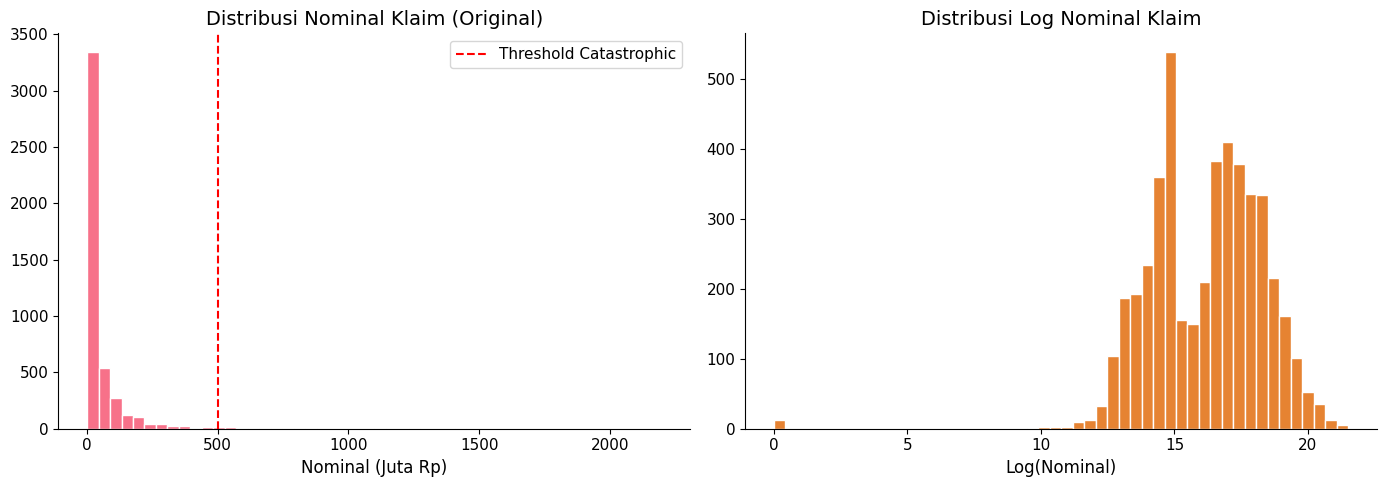

In [5]:
# Log-Transform nominal
df['Log_Nominal'] = np.log1p(df['Nominal Klaim Yang Disetujui'].fillna(0))
df['Log_Biaya_RS'] = np.log1p(df['Nominal Biaya RS Yang Terjadi'].fillna(0))

# Pisahkan Regular vs Catastrophic
CATASTROPHIC_THRESHOLD = 500_000_000
df['Is_Catastrophic'] = df['Nominal Klaim Yang Disetujui'] > CATASTROPHIC_THRESHOLD
df['Claim_Category'] = df['Is_Catastrophic'].map({True: 'Catastrophic (>500M)', False: 'Regular'})

n_cat = df['Is_Catastrophic'].sum()
total_cat = df.loc[df['Is_Catastrophic'], 'Nominal Klaim Yang Disetujui'].sum()
total_all = df['Nominal Klaim Yang Disetujui'].sum()

print(f"💰 Klaim Catastrophic (>500 Juta): {n_cat} klaim ({n_cat/len(df)*100:.1f}%)")
print(f"   Total nominal catastrophic: Rp {total_cat/1e9:.1f} Miliar ({total_cat/total_all*100:.1f}% dari total)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Nominal Klaim Yang Disetujui'].dropna()/1e6, bins=50, color=COLORS[0], edgecolor='white')
axes[0].set_title('Distribusi Nominal Klaim (Original)')
axes[0].set_xlabel('Nominal (Juta Rp)')
axes[0].axvline(500, color='red', linestyle='--', label='Threshold Catastrophic')
axes[0].legend()

axes[1].hist(df['Log_Nominal'].dropna(), bins=50, color=COLORS[1], edgecolor='white')
axes[1].set_title('Distribusi Log Nominal Klaim')
axes[1].set_xlabel('Log(Nominal)')
plt.tight_layout()
plt.show()

---
## Phase 1: Medical Tourism Deep Dive

### 1.1 Profil Nasabah yang Berobat ke Luar Negeri

In [6]:
overseas = df[df['Is_Overseas']].copy()
domestic = df[~df['Is_Overseas']].copy()

print(f"🌏 Total klaim luar negeri: {len(overseas):,} ({len(overseas)/len(df)*100:.1f}%)")
print(f"   Total nominal: Rp {overseas['Nominal Klaim Yang Disetujui'].sum()/1e9:.1f} Miliar")
print(f"\n📊 Breakdown per negara:")
print(overseas['Lokasi RS'].value_counts().to_string())

🌏 Total klaim luar negeri: 1,517 (32.8%)
   Total nominal: Rp 149.8 Miliar

📊 Breakdown per negara:
Lokasi RS
Singapore    1019
Malaysia      456
Overseas       28
Others          6
Taiwan          5
Hong Kong       1
Japan           1
Tiongkok        1


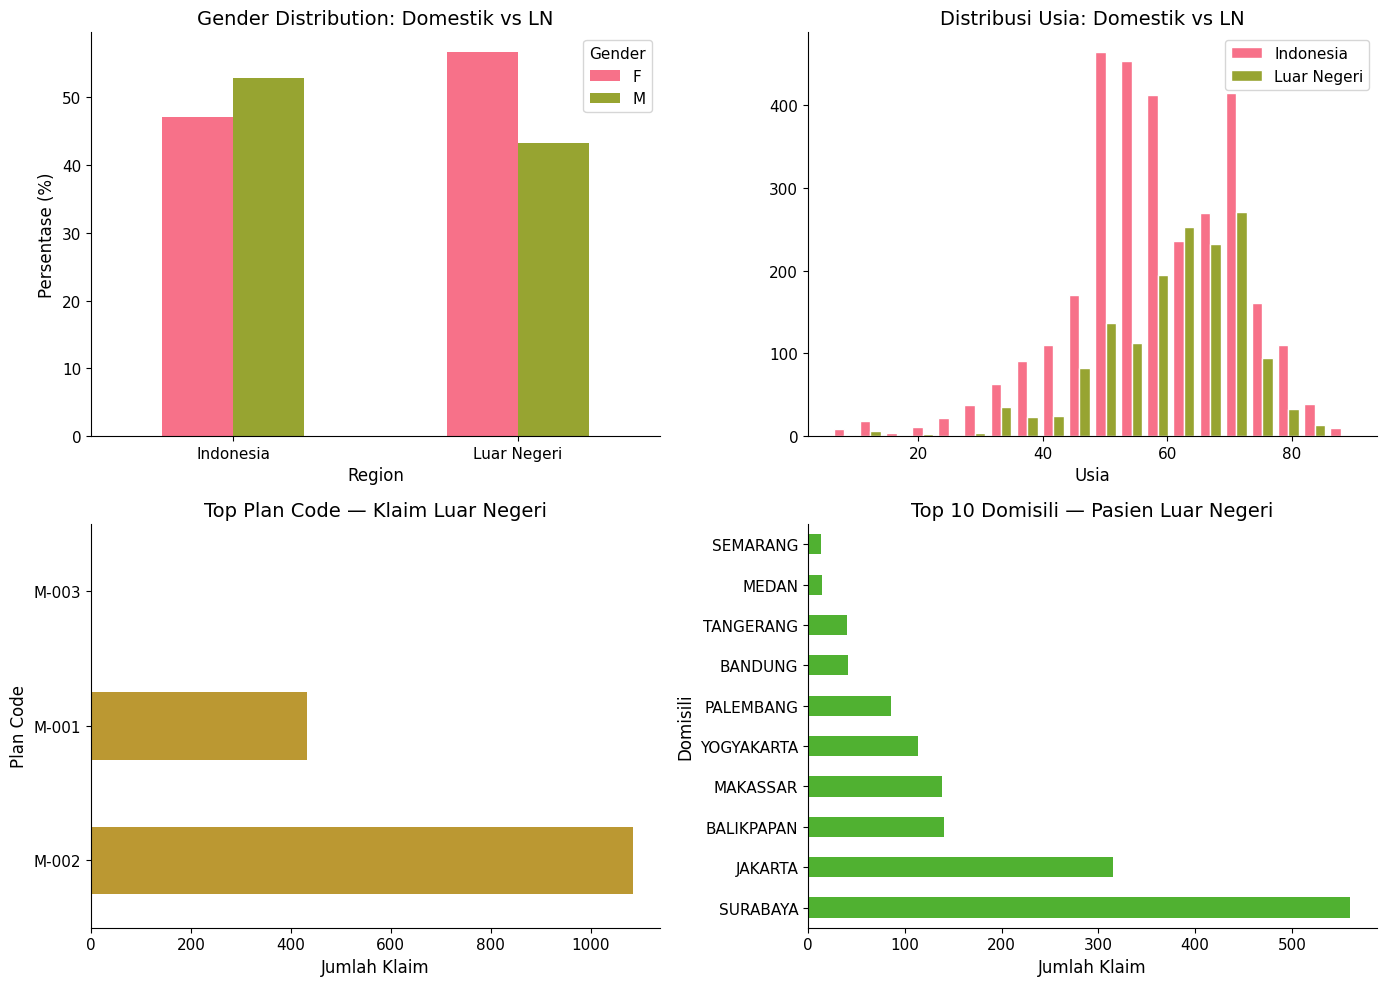

In [7]:
# Profil demografi overseas vs domestic
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_data = pd.crosstab(df['Region'], df['Gender'], normalize='index') * 100
gender_data.plot(kind='bar', ax=axes[0,0], color=[COLORS[0], COLORS[3]])
axes[0,0].set_title('Gender Distribution: Domestik vs LN')
axes[0,0].set_ylabel('Persentase (%)')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].legend(title='Gender')

# Usia
axes[0,1].hist([domestic['Usia'].dropna(), overseas['Usia'].dropna()],
               bins=20, label=['Indonesia', 'Luar Negeri'], color=[COLORS[0], COLORS[3]], edgecolor='white')
axes[0,1].set_title('Distribusi Usia: Domestik vs LN')
axes[0,1].set_xlabel('Usia')
axes[0,1].legend()

# Plan Code
plan_overseas = overseas['Plan Code'].value_counts().head(8)
plan_overseas.plot(kind='barh', ax=axes[1,0], color=COLORS[2])
axes[1,0].set_title('Top Plan Code — Klaim Luar Negeri')
axes[1,0].set_xlabel('Jumlah Klaim')

# Domisili
dom_overseas = overseas['Domisili'].value_counts().head(10)
dom_overseas.plot(kind='barh', ax=axes[1,1], color=COLORS[4])
axes[1,1].set_title('Top 10 Domisili — Pasien Luar Negeri')
axes[1,1].set_xlabel('Jumlah Klaim')

plt.tight_layout()
plt.show()

### 1.2 Perbandingan Biaya per Diagnosis: Indonesia vs Luar Negeri

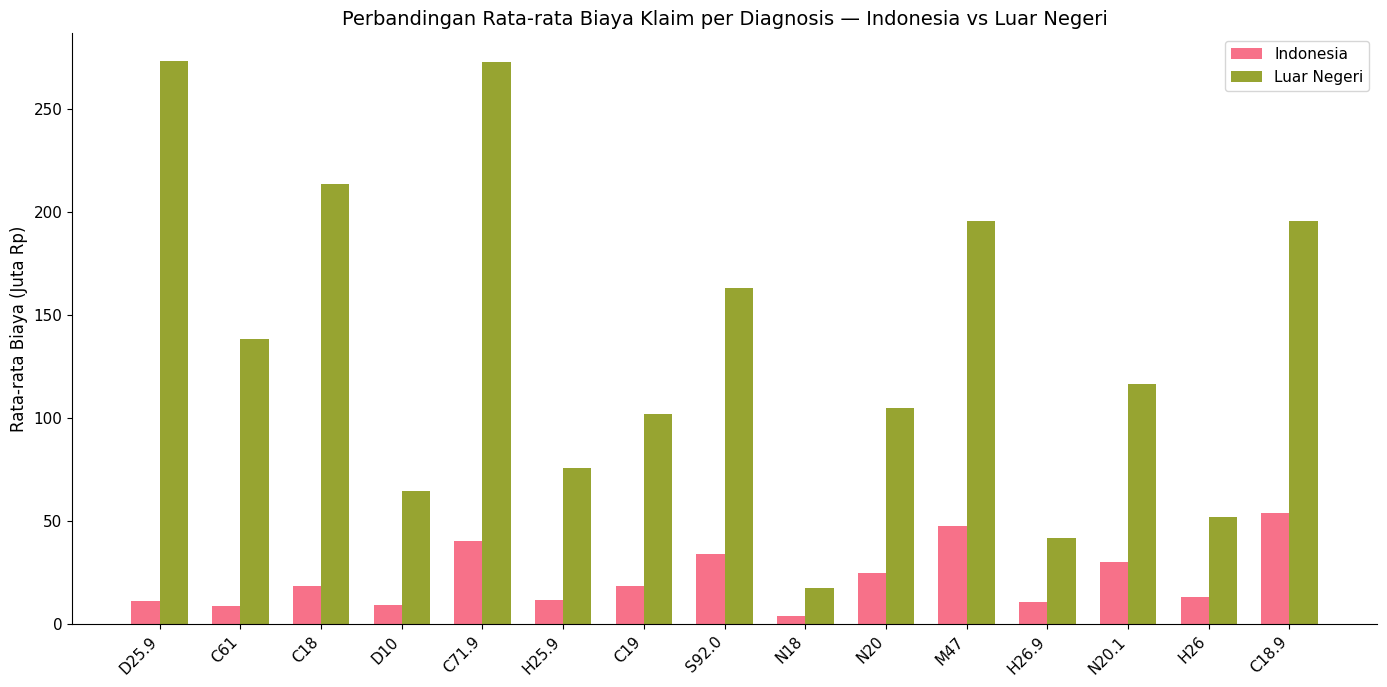


📊 Rasio Biaya Luar Negeri / Indonesia:
   D25.9: 24.4x lebih mahal di LN
   C61: 15.3x lebih mahal di LN
   C18: 11.5x lebih mahal di LN
   D10: 6.8x lebih mahal di LN
   C71.9: 6.7x lebih mahal di LN
   H25.9: 6.4x lebih mahal di LN
   C19: 5.4x lebih mahal di LN
   S92.0: 4.8x lebih mahal di LN
   N18: 4.6x lebih mahal di LN
   N20: 4.2x lebih mahal di LN
   M47: 4.1x lebih mahal di LN
   H26.9: 3.9x lebih mahal di LN
   N20.1: 3.9x lebih mahal di LN
   H26: 3.9x lebih mahal di LN
   C18.9: 3.6x lebih mahal di LN


In [8]:
# Top diagnosis yang ada di kedua region
diag_both = df.groupby(['ICD Diagnosis', 'Region'])['Nominal Klaim Yang Disetujui'].agg(['mean','count'])
diag_both = diag_both.reset_index()
diag_pivot = diag_both.pivot(index='ICD Diagnosis', columns='Region', values='mean')
diag_count = diag_both.pivot(index='ICD Diagnosis', columns='Region', values='count')

# Filter diagnosis yang ada di kedua region dengan min 3 klaim
mask = (diag_count['Indonesia'].fillna(0) >= 3) & (diag_count['Luar Negeri'].fillna(0) >= 3)
diag_compare = diag_pivot[mask].dropna().copy()
diag_compare['Rasio_LN_vs_ID'] = diag_compare['Luar Negeri'] / diag_compare['Indonesia']
diag_compare = diag_compare.sort_values('Rasio_LN_vs_ID', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(diag_compare))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], diag_compare['Indonesia']/1e6, width, label='Indonesia', color=COLORS[0])
bars2 = ax.bar([i + width/2 for i in x], diag_compare['Luar Negeri']/1e6, width, label='Luar Negeri', color=COLORS[3])
ax.set_xticks(x)
ax.set_xticklabels(diag_compare.index, rotation=45, ha='right')
ax.set_ylabel('Rata-rata Biaya (Juta Rp)')
ax.set_title('Perbandingan Rata-rata Biaya Klaim per Diagnosis — Indonesia vs Luar Negeri')
ax.legend()
plt.tight_layout()
plt.show()

print("\n📊 Rasio Biaya Luar Negeri / Indonesia:")
for diag, row in diag_compare.iterrows():
    print(f"   {diag}: {row['Rasio_LN_vs_ID']:.1f}x lebih mahal di LN")

### 1.3 Diagnosis yang "Harus" ke Luar Negeri vs Bisa di Indonesia

In [9]:
# Diagnosis yang mayoritas (>70%) dirawat di luar negeri
diag_region = df.groupby('ICD Diagnosis').agg(
    total=('Claim ID', 'count'),
    overseas_count=('Is_Overseas', 'sum'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()
diag_region['overseas_pct'] = diag_region['overseas_count'] / diag_region['total'] * 100

# Filter min 20 klaim
diag_region_sig = diag_region[diag_region['total'] >= 20].sort_values('overseas_pct', ascending=False)

print("🏥 Diagnosis yang MAYORITAS (>70%) dirawat di Luar Negeri:")
harus_ln = diag_region_sig[diag_region_sig['overseas_pct'] > 70]
if len(harus_ln) > 0:
    for _, row in harus_ln.head(10).iterrows():
        desc = df[df['ICD Diagnosis'] == row['ICD Diagnosis']]['ICD Description'].iloc[0]
        print(f"   {row['ICD Diagnosis']} ({desc}): {row['overseas_pct']:.0f}% LN, avg Rp {row['avg_nominal']/1e6:.0f}jt")
else:
    print("   Tidak ada diagnosis dengan >70% klaim di LN (dengan min 20 klaim)")

print("\n🏥 Diagnosis yang BISA ditangani di Indonesia (>80% domestik) tapi tetap ada yang ke LN:")
bisa_id = diag_region_sig[(diag_region_sig['overseas_pct'] > 0) & (diag_region_sig['overseas_pct'] <= 20)]
for _, row in bisa_id.head(10).iterrows():
    desc = df[df['ICD Diagnosis'] == row['ICD Diagnosis']]['ICD Description'].iloc[0]
    print(f"   {row['ICD Diagnosis']} ({desc}): {row['overseas_pct']:.0f}% LN, avg Rp {row['avg_nominal']/1e6:.0f}jt")

🏥 Diagnosis yang MAYORITAS (>70%) dirawat di Luar Negeri:
   C25 (MALIGNANT NEOPLASM OF PANCREAS): 100% LN, avg Rp 86jt
   C56 (Malignant neoplasm of ovari): 100% LN, avg Rp 29jt
   C90.0 (Multiple myeloma): 100% LN, avg Rp 101jt
   C34.9 (MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED): 93% LN, avg Rp 164jt
   C61 (MALIGNANT NEOPLASM OF PROSTAT): 76% LN, avg Rp 108jt
   C18 (Malignant neoplasm of colon): 76% LN, avg Rp 167jt
   I84 (Haemorrhoids (ambein)): 75% LN, avg Rp 56jt

🏥 Diagnosis yang BISA ditangani di Indonesia (>80% domestik) tapi tetap ada yang ke LN:
   I10 (ESSENTIAL (PRIMARY) HYPERTENSION): 19% LN, avg Rp 29jt
   C18.9 (MALIGNANT NEOPLASM, COLON, UNSPECIFIED): 18% LN, avg Rp 80jt
   N20 (Urolithiasis): 12% LN, avg Rp 34jt
   C19 (MALIGNANT NEOPLASM OF RECTOSIGMOID JUNCTION): 12% LN, avg Rp 28jt
   A90 (DENGUE FEVER [CLASSICAL DENGUE]): 7% LN, avg Rp 21jt
   R10 (ABDOMINAL AND PELVIC PAIN): 6% LN, avg Rp 21jt
   M54.5 (Low back pain (Nyeri punggung)): 5% LN, avg Rp 68

### 1.4 Heatmap: Domisili × Lokasi RS

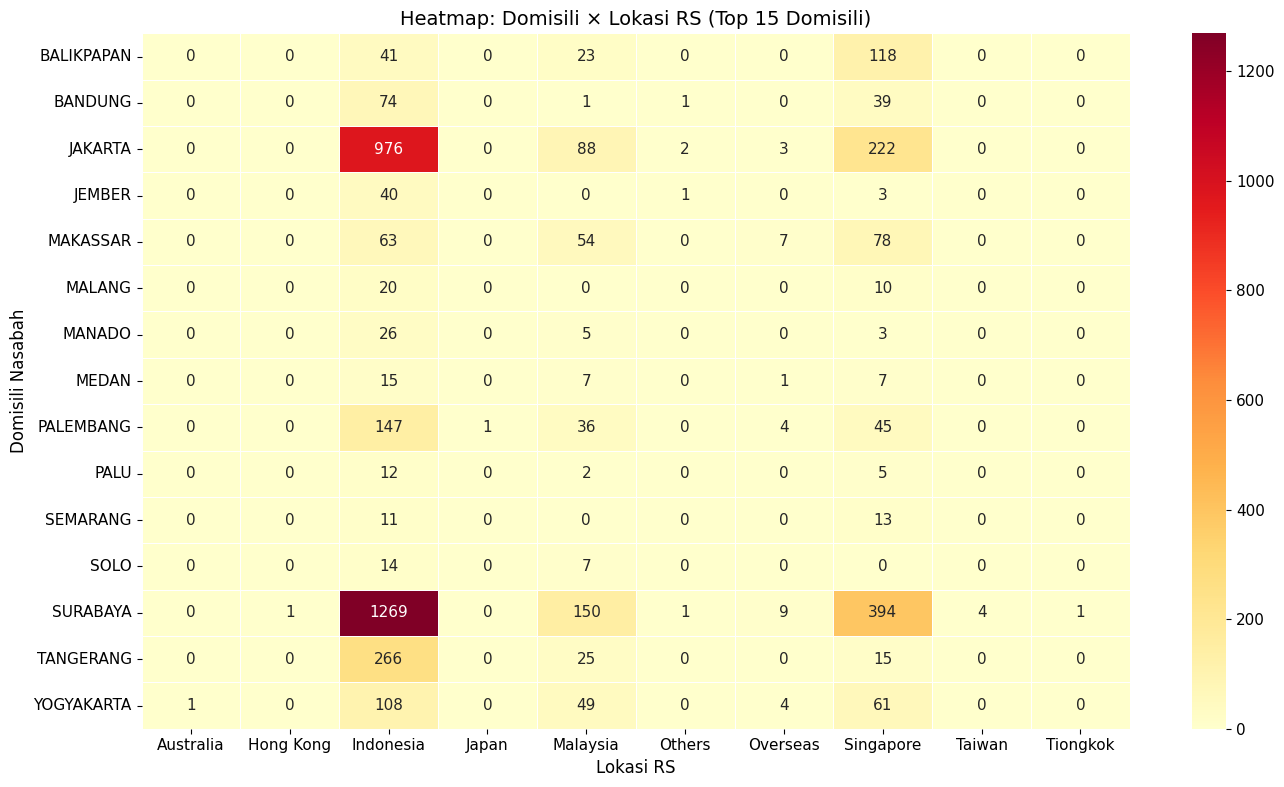


💡 Insight: Kota mana yang paling banyak mengirim pasien ke luar negeri?
   SURABAYA: 560 klaim LN (30.6% dari total klaim domisili)
   JAKARTA: 315 klaim LN (24.3% dari total klaim domisili)
   BALIKPAPAN: 141 klaim LN (77.5% dari total klaim domisili)
   MAKASSAR: 139 klaim LN (68.5% dari total klaim domisili)
   YOGYAKARTA: 114 klaim LN (50.9% dari total klaim domisili)


In [10]:
heatmap_data = pd.crosstab(df['Domisili'], df['Lokasi RS'])
# Filter top domisili
top_dom = df['Domisili'].value_counts().head(15).index
heatmap_filtered = heatmap_data.loc[heatmap_data.index.isin(top_dom)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_filtered, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmap: Domisili × Lokasi RS (Top 15 Domisili)')
ax.set_ylabel('Domisili Nasabah')
ax.set_xlabel('Lokasi RS')
plt.tight_layout()
plt.show()

print("\n💡 Insight: Kota mana yang paling banyak mengirim pasien ke luar negeri?")
overseas_by_dom = df[df['Is_Overseas']].groupby('Domisili').size().sort_values(ascending=False).head(5)
for dom, count in overseas_by_dom.items():
    pct = count / df[df['Domisili'] == dom].shape[0] * 100
    print(f"   {dom}: {count} klaim LN ({pct:.1f}% dari total klaim domisili)")

---
## Phase 2: Kanker sebagai Cost Driver

Isolasi semua klaim ICD C* (Neoplasma Ganas) dan D* (Neoplasma Jinak/Darah) untuk analisis mendalam.

In [11]:
# Isolasi klaim kanker
df['Is_Cancer'] = df['ICD_Letter'].isin(['C', 'D'])
cancer = df[df['Is_Cancer']].copy()
non_cancer = df[~df['Is_Cancer']].copy()

print(f"🎗️  Klaim Kanker (ICD C* + D*): {len(cancer):,} ({len(cancer)/len(df)*100:.1f}%)")
print(f"   Total Nominal: Rp {cancer['Nominal Klaim Yang Disetujui'].sum()/1e9:.1f} Miliar")
print(f"   Share dari total: {cancer['Nominal Klaim Yang Disetujui'].sum()/df['Nominal Klaim Yang Disetujui'].sum()*100:.1f}%")
print(f"\n   Breakdown ICD Letter:")
print(f"   C (Neoplasma Ganas): {(df['ICD_Letter']=='C').sum()} klaim")
print(f"   D (Neoplasma Jinak/Darah): {(df['ICD_Letter']=='D').sum()} klaim")

🎗️  Klaim Kanker (ICD C* + D*): 1,078 (23.3%)
   Total Nominal: Rp 84.8 Miliar
   Share dari total: 33.3%

   Breakdown ICD Letter:
   C (Neoplasma Ganas): 934 klaim
   D (Neoplasma Jinak/Darah): 144 klaim


### 2.1 Long-tail Cost Analysis per Polis Kanker

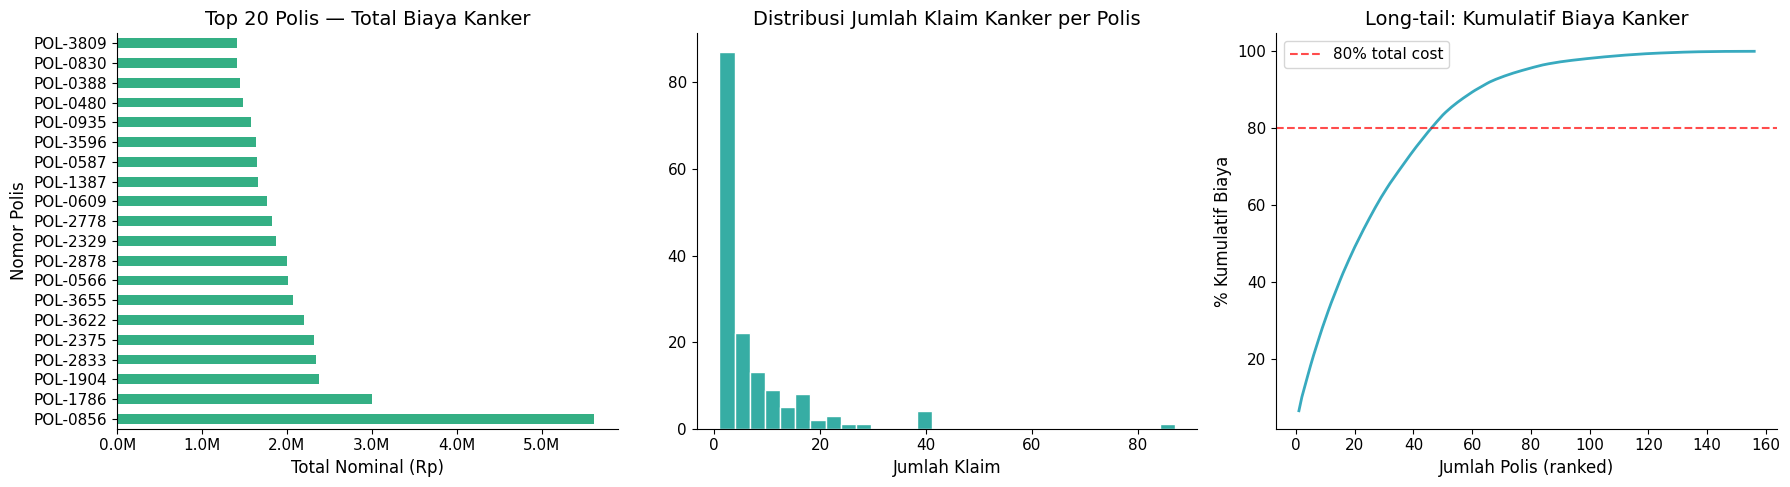


💡 46 polis (29%) menguasai 80% total biaya kanker


In [12]:
# Total nominal per polis kanker
cancer_by_polis = cancer.groupby('Nomor Polis').agg(
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    jumlah_klaim=('Claim ID', 'count'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    diagnoses=('ICD Diagnosis', 'nunique')
).sort_values('total_nominal', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 20 polis termahal
cancer_by_polis.head(20)['total_nominal'].plot(kind='barh', ax=axes[0], color=COLORS[5])
axes[0].set_title('Top 20 Polis — Total Biaya Kanker')
axes[0].set_xlabel('Total Nominal (Rp)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}M'))

# Distribusi jumlah klaim per polis
axes[1].hist(cancer_by_polis['jumlah_klaim'], bins=30, color=COLORS[6], edgecolor='white')
axes[1].set_title('Distribusi Jumlah Klaim Kanker per Polis')
axes[1].set_xlabel('Jumlah Klaim')

# Long-tail: cumulative share
sorted_nominal = cancer_by_polis['total_nominal'].sort_values(ascending=False)
cumsum = sorted_nominal.cumsum() / sorted_nominal.sum() * 100
axes[2].plot(range(1, len(cumsum)+1), cumsum.values, color=COLORS[7], linewidth=2)
axes[2].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% total cost')
axes[2].set_title('Long-tail: Kumulatif Biaya Kanker')
axes[2].set_xlabel('Jumlah Polis (ranked)')
axes[2].set_ylabel('% Kumulatif Biaya')
axes[2].legend()

plt.tight_layout()
plt.show()

n80 = (cumsum <= 80).sum()
print(f"\n💡 {n80} polis ({n80/len(cancer_by_polis)*100:.0f}%) menguasai 80% total biaya kanker")

### 2.2 Rasio Coverage Kanker vs Non-Kanker

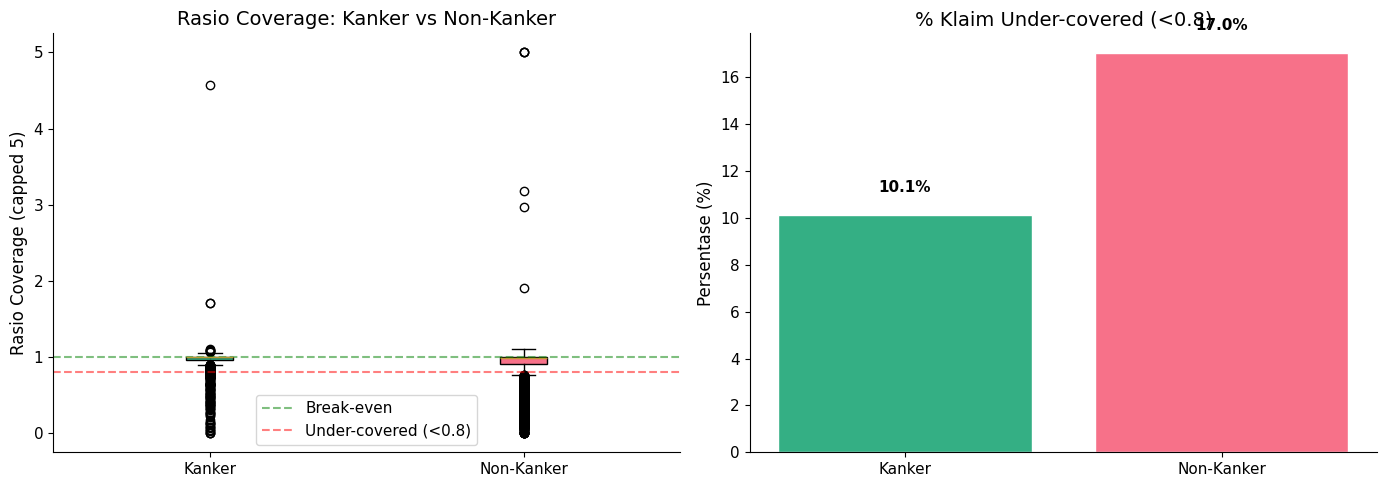

💡 Kanker under-covered: 10.1% | Non-kanker: 17.0%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot rasio coverage
coverage_data = [
    cancer['Rasio_Coverage'].dropna().clip(0, 5),
    non_cancer['Rasio_Coverage'].dropna().clip(0, 5)
]
bp = axes[0].boxplot(coverage_data, labels=['Kanker', 'Non-Kanker'], patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS[5])
bp['boxes'][1].set_facecolor(COLORS[0])
axes[0].set_title('Rasio Coverage: Kanker vs Non-Kanker')
axes[0].set_ylabel('Rasio Coverage (capped 5)')
axes[0].axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Break-even')
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Under-covered (<0.8)')
axes[0].legend()

# Persentase under-covered
under_cancer = (cancer['Rasio_Coverage'] < 0.8).mean() * 100
under_noncancer = (non_cancer['Rasio_Coverage'] < 0.8).mean() * 100
bars = axes[1].bar(['Kanker', 'Non-Kanker'], [under_cancer, under_noncancer],
                   color=[COLORS[5], COLORS[0]], edgecolor='white')
axes[1].set_title('% Klaim Under-covered (<0.8)')
axes[1].set_ylabel('Persentase (%)')
for bar, val in zip(bars, [under_cancer, under_noncancer]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"💡 Kanker under-covered: {under_cancer:.1f}% | Non-kanker: {under_noncancer:.1f}%")

### 2.3 Kanker: Indonesia vs Luar Negeri

🌏 Perbandingan Klaim Kanker: Indonesia vs Luar Negeri


,jumlah,avg_nominal,median_nominal,total_nominal,avg_los,avg_nominal_juta,total_nominal_miliar
Region,,,,,,,
Indonesia,500,41931864.0,14980104.0,2.096593e+10,1.0,41.931864,20.965932
Luar Negeri,578,110415169.0,52181034.0,6.381997e+10,1.0,110.415169,63.819968


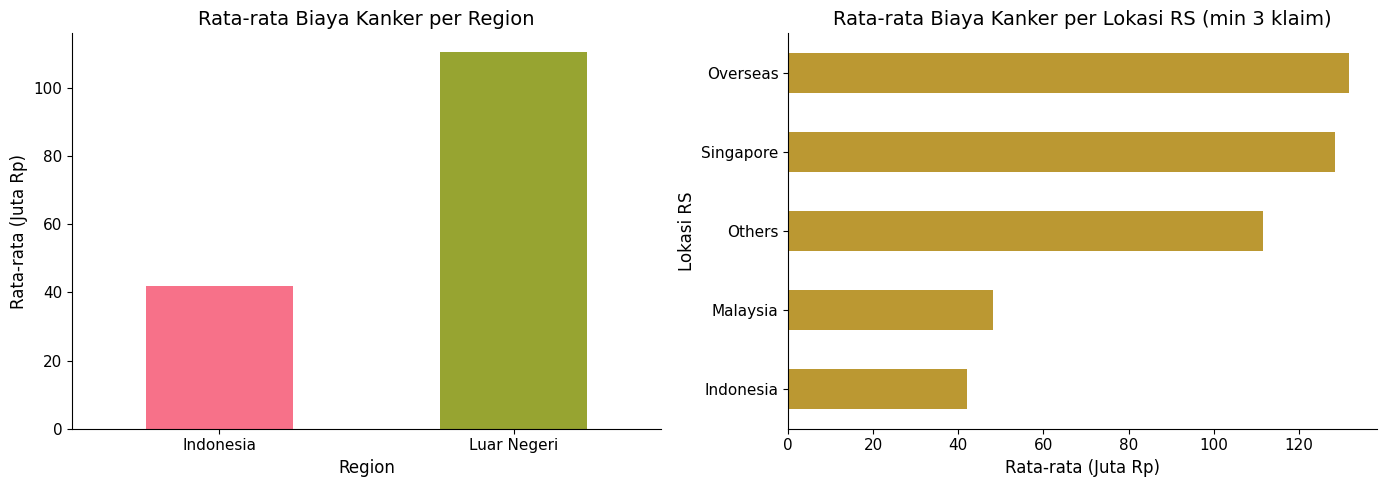

In [14]:
cancer_region = cancer.groupby('Region').agg(
    jumlah=('Claim ID', 'count'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    median_nominal=('Nominal Klaim Yang Disetujui', 'median'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    avg_los=('LOS', 'mean')
).round(0)
cancer_region['avg_nominal_juta'] = cancer_region['avg_nominal'] / 1e6
cancer_region['total_nominal_miliar'] = cancer_region['total_nominal'] / 1e9

print("🌏 Perbandingan Klaim Kanker: Indonesia vs Luar Negeri")
display(cancer_region)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cancer_region['avg_nominal_juta'].plot(kind='bar', ax=axes[0], color=[COLORS[0], COLORS[3]])
axes[0].set_title('Rata-rata Biaya Kanker per Region')
axes[0].set_ylabel('Rata-rata (Juta Rp)')
axes[0].tick_params(axis='x', rotation=0)

# Detail per negara
cancer_country = cancer.groupby('Lokasi RS')['Nominal Klaim Yang Disetujui'].agg(['mean','count'])
cancer_country = cancer_country[cancer_country['count'] >= 3].sort_values('mean', ascending=True)
cancer_country['mean_juta'] = cancer_country['mean'] / 1e6
cancer_country['mean_juta'].plot(kind='barh', ax=axes[1], color=COLORS[2])
axes[1].set_title('Rata-rata Biaya Kanker per Lokasi RS (min 3 klaim)')
axes[1].set_xlabel('Rata-rata (Juta Rp)')

plt.tight_layout()
plt.show()

---
## Phase 3: Efisiensi Pemrosesan Klaim

### 3.1 Nominal vs Processing Days

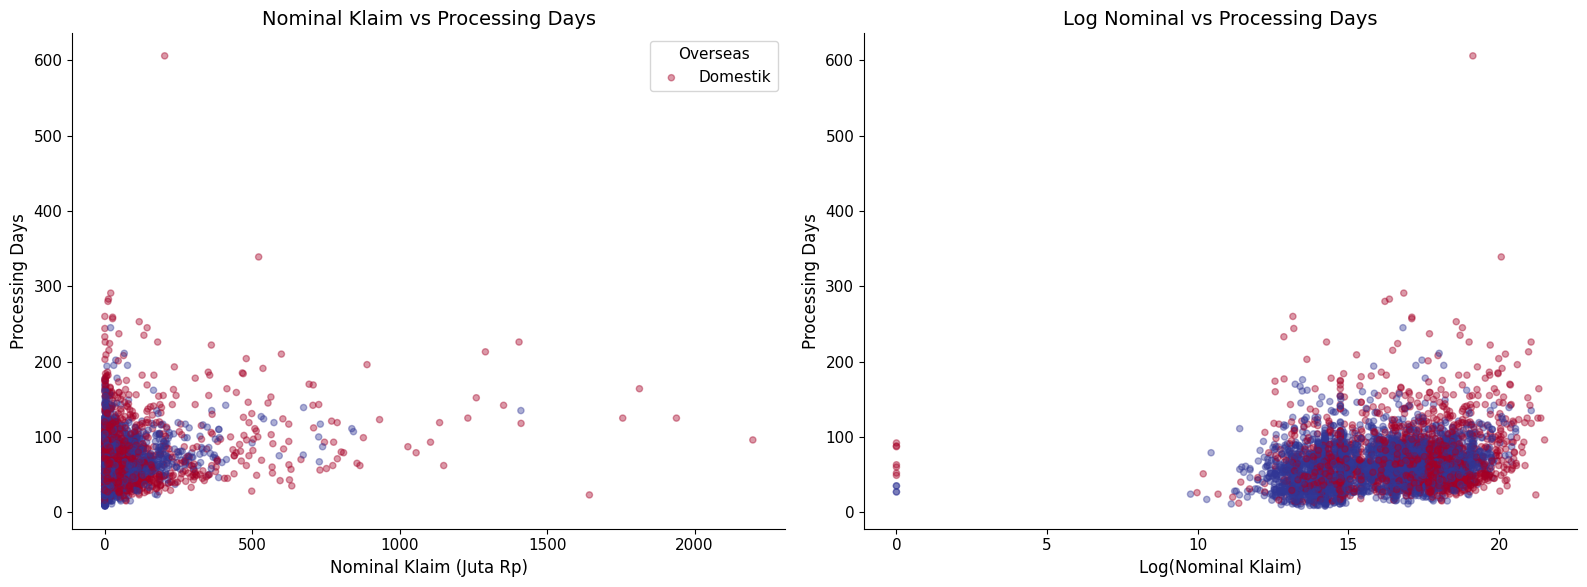

📊 Korelasi Nominal vs Processing Days: 0.227


In [15]:
valid_proc = df.dropna(subset=['Processing_Days', 'Nominal Klaim Yang Disetujui'])
valid_proc = valid_proc[valid_proc['Processing_Days'] >= 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = axes[0].scatter(valid_proc['Nominal Klaim Yang Disetujui']/1e6,
                          valid_proc['Processing_Days'],
                          c=valid_proc['Is_Overseas'].astype(int),
                          cmap='RdYlBu_r', alpha=0.4, s=20)
axes[0].set_xlabel('Nominal Klaim (Juta Rp)')
axes[0].set_ylabel('Processing Days')
axes[0].set_title('Nominal Klaim vs Processing Days')
axes[0].legend(*scatter.legend_elements(), title='Overseas', labels=['Domestik', 'Luar Negeri'])

# Log-scale version
axes[1].scatter(valid_proc['Log_Nominal'], valid_proc['Processing_Days'],
                c=valid_proc['Is_Overseas'].astype(int), cmap='RdYlBu_r', alpha=0.4, s=20)
axes[1].set_xlabel('Log(Nominal Klaim)')
axes[1].set_ylabel('Processing Days')
axes[1].set_title('Log Nominal vs Processing Days')

plt.tight_layout()
plt.show()

corr = valid_proc[['Nominal Klaim Yang Disetujui', 'Processing_Days']].corr().iloc[0,1]
print(f"📊 Korelasi Nominal vs Processing Days: {corr:.3f}")

### 3.2 Processing Time per Kategori Nominal

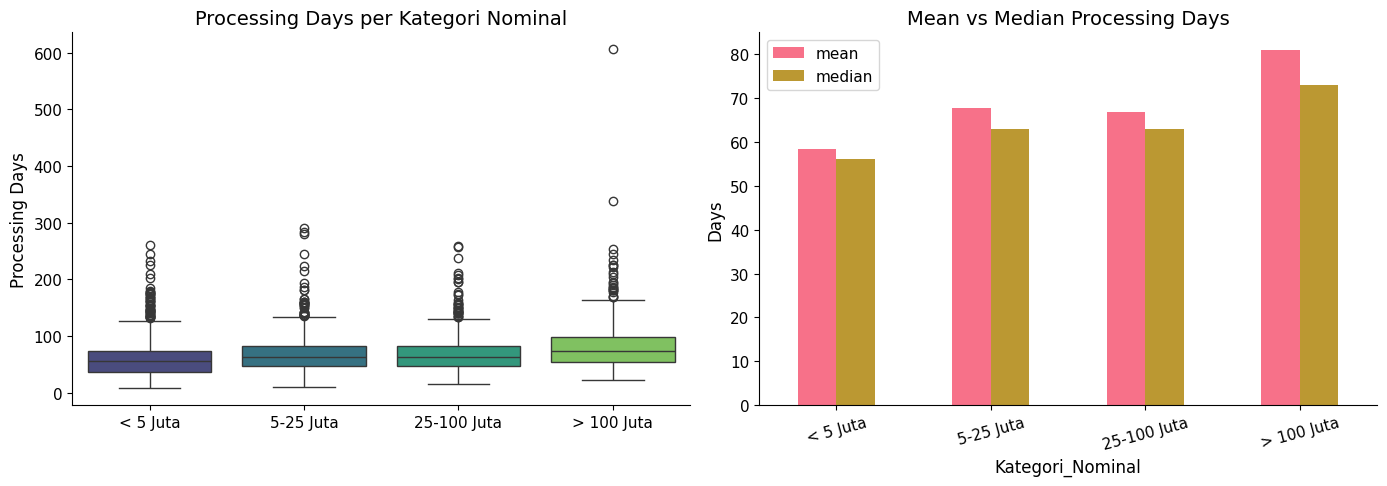

                  mean  median   std
Kategori_Nominal                    
< 5 Juta          58.3    56.0  30.3
5-25 Juta         67.8    63.0  31.7
25-100 Juta       66.8    63.0  29.3
> 100 Juta        80.9    73.0  44.2


In [16]:
kat_order = ['< 5 Juta', '5-25 Juta', '25-100 Juta', '> 100 Juta']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Kategori_Nominal', y='Processing_Days', order=kat_order,
            palette='viridis', ax=axes[0])
axes[0].set_title('Processing Days per Kategori Nominal')
axes[0].set_ylabel('Processing Days')
axes[0].set_xlabel('')

stats = df.groupby('Kategori_Nominal')['Processing_Days'].agg(['mean','median','std']).reindex(kat_order)
stats[['mean','median']].plot(kind='bar', ax=axes[1], color=[COLORS[0], COLORS[2]])
axes[1].set_title('Mean vs Median Processing Days')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(stats.round(1).to_string())

### 3.3 Heatmap: Processing Days per Lokasi RS × Jenis Rawat

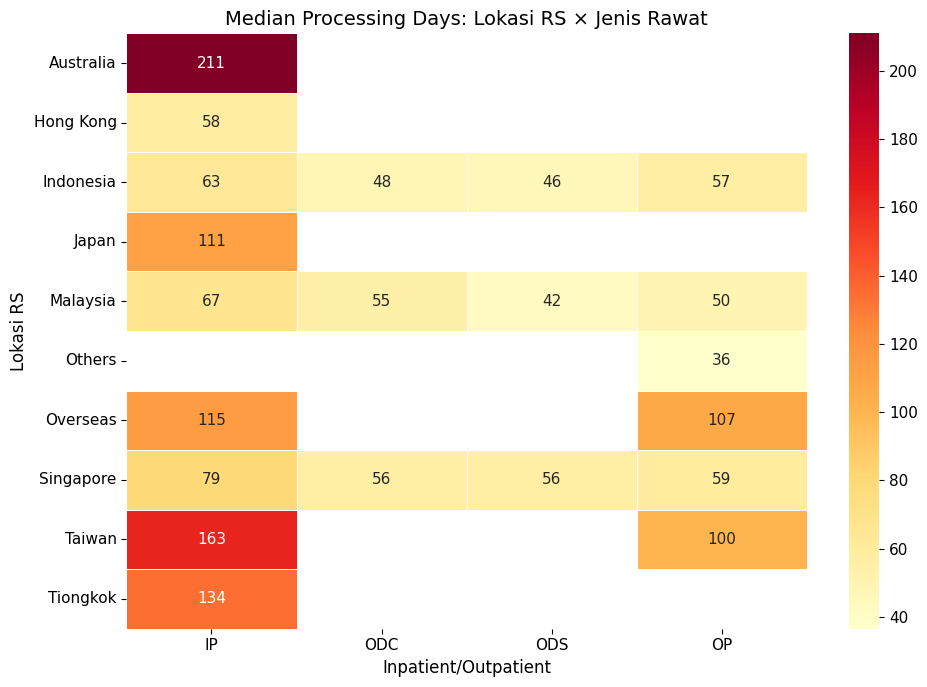

In [17]:
proc_heatmap = df.pivot_table(values='Processing_Days', index='Lokasi RS',
                              columns='Inpatient/Outpatient', aggfunc='median')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(proc_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Median Processing Days: Lokasi RS × Jenis Rawat')
plt.tight_layout()
plt.show()

### 3.4 Inefisiensi: Klaim Kecil tapi Processing Lama

⚠️  Klaim kecil (<5 Juta) dengan processing >30 hari: 1478 klaim
   Median processing: 62 hari
   Breakdown Reimburse/Cashless:
Reimburse/Cashless
R    890
C    588

   Breakdown Lokasi RS:
Lokasi RS
Indonesia    1110
Singapore     227
Malaysia      133
Overseas        3
Taiwan          2


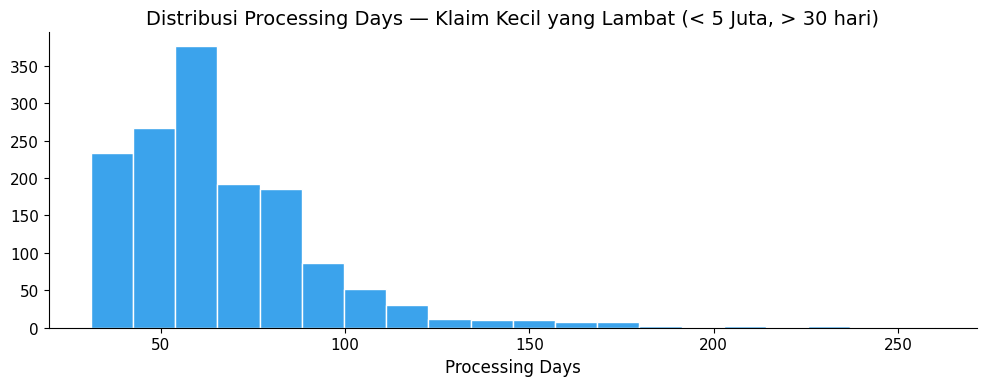

In [18]:
# Klaim < 5 Juta tapi processing > 30 hari
small_slow = df[(df['Kategori_Nominal'] == '< 5 Juta') & (df['Processing_Days'] > 30)]
print(f"⚠️  Klaim kecil (<5 Juta) dengan processing >30 hari: {len(small_slow)} klaim")
print(f"   Median processing: {small_slow['Processing_Days'].median():.0f} hari")
print(f"   Breakdown Reimburse/Cashless:")
print(small_slow['Reimburse/Cashless'].value_counts().to_string())
print(f"\n   Breakdown Lokasi RS:")
print(small_slow['Lokasi RS'].value_counts().head(5).to_string())

if len(small_slow) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(small_slow['Processing_Days'], bins=20, color=COLORS[8], edgecolor='white')
    ax.set_title('Distribusi Processing Days — Klaim Kecil yang Lambat (< 5 Juta, > 30 hari)')
    ax.set_xlabel('Processing Days')
    plt.tight_layout()
    plt.show()

---
## Phase 4: Seasonality Penyakit

### 4.1 Time Series Klaim per Bulan — Top 5 ICD Group

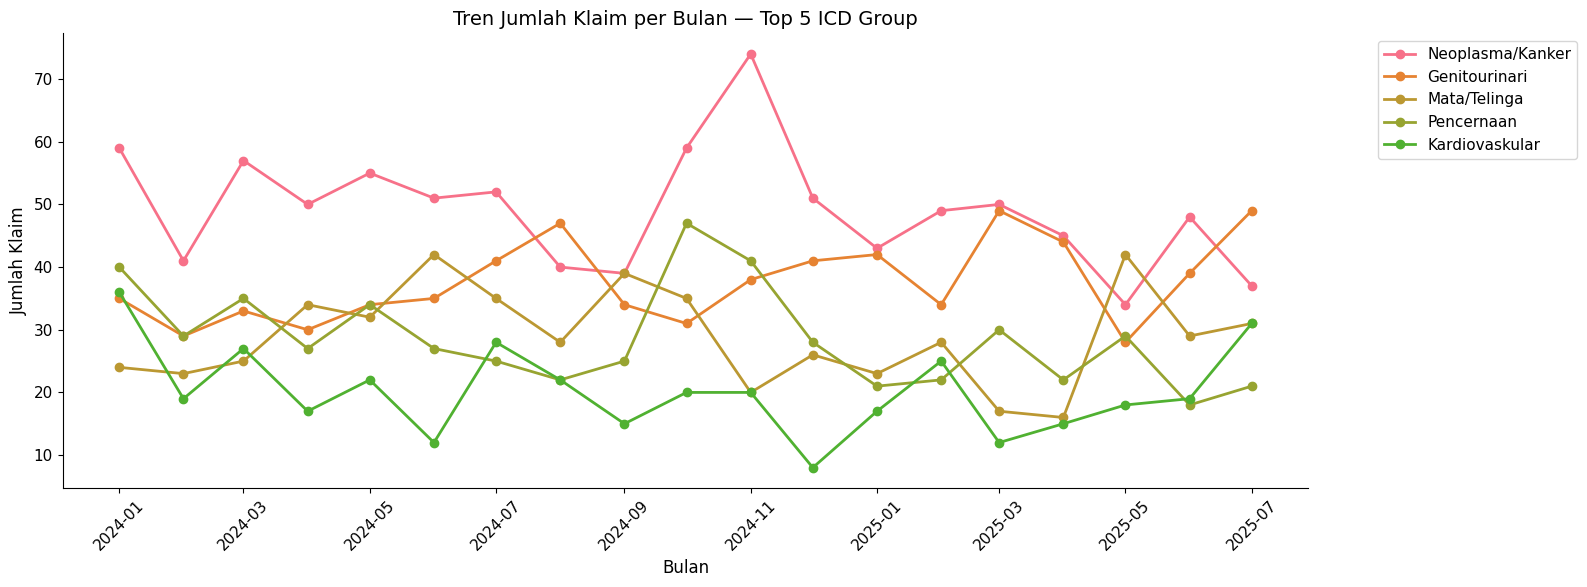

In [19]:
df['Bulan_dt'] = pd.to_datetime(df['Bulan'], format='%Y-%m', errors='coerce')
top5_groups = df['ICD_Group'].value_counts().head(5).index.tolist()

monthly_group = df[df['ICD_Group'].isin(top5_groups)].groupby(
    ['Bulan_dt', 'ICD_Group']).size().reset_index(name='Jumlah')

fig, ax = plt.subplots(figsize=(16, 6))
for i, grp in enumerate(top5_groups):
    data = monthly_group[monthly_group['ICD_Group'] == grp]
    ax.plot(data['Bulan_dt'], data['Jumlah'], marker='o', label=grp, linewidth=2, color=COLORS[i])
ax.set_title('Tren Jumlah Klaim per Bulan — Top 5 ICD Group')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Klaim')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Pola Musiman — Analisis per Kuartal

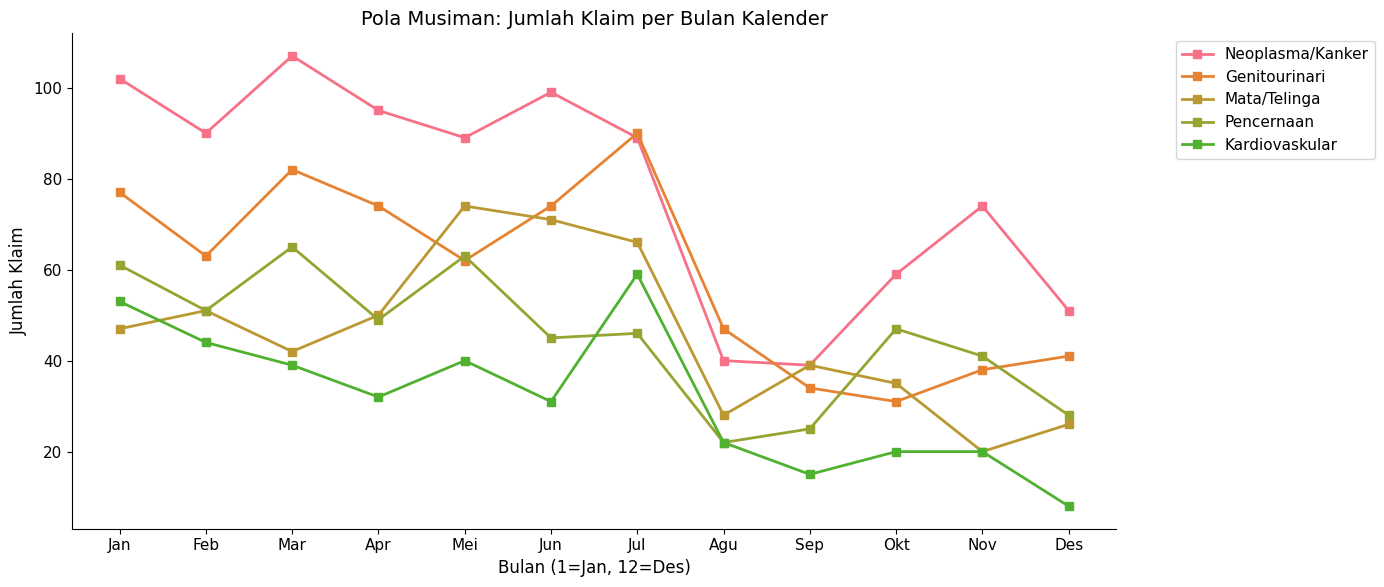

In [20]:
# Buat kolom bulan-angka untuk analisis musiman
df['Bulan_Num'] = df['Bulan_dt'].dt.month

monthly_seasonal = df[df['ICD_Group'].isin(top5_groups)].groupby(
    ['Bulan_Num', 'ICD_Group']).size().reset_index(name='Avg_Klaim')

fig, ax = plt.subplots(figsize=(14, 6))
for i, grp in enumerate(top5_groups):
    data = monthly_seasonal[monthly_seasonal['ICD_Group'] == grp]
    ax.plot(data['Bulan_Num'], data['Avg_Klaim'], marker='s', label=grp, linewidth=2, color=COLORS[i])
ax.set_title('Pola Musiman: Jumlah Klaim per Bulan Kalender')
ax.set_xlabel('Bulan (1=Jan, 12=Des)')
ax.set_ylabel('Jumlah Klaim')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.3 Tren Kanker: Stabil atau Meningkat?

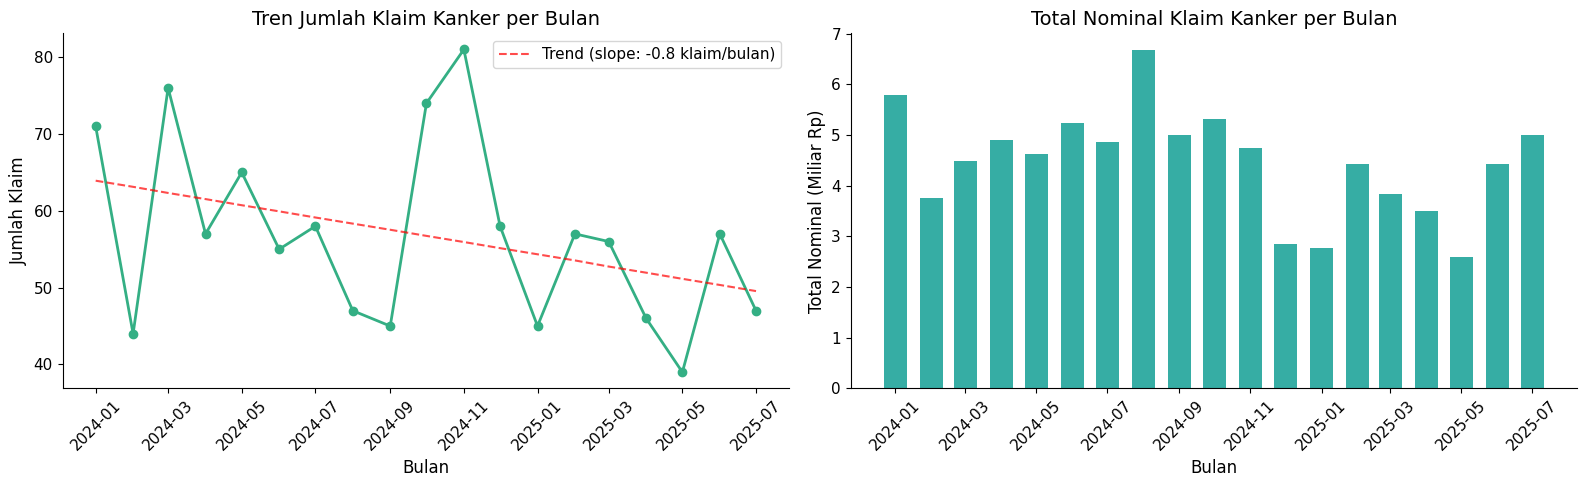

In [21]:
cancer_monthly = df[df['Is_Cancer']].groupby('Bulan_dt').agg(
    jumlah_klaim=('Claim ID', 'count'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(cancer_monthly['Bulan_dt'], cancer_monthly['jumlah_klaim'],
             marker='o', color=COLORS[5], linewidth=2)
axes[0].set_title('Tren Jumlah Klaim Kanker per Bulan')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=45)

# Trend line
if len(cancer_monthly) > 2:
    x_num = np.arange(len(cancer_monthly))
    z = np.polyfit(x_num, cancer_monthly['jumlah_klaim'], 1)
    p = np.poly1d(z)
    axes[0].plot(cancer_monthly['Bulan_dt'], p(x_num), '--', color='red', alpha=0.7,
                 label=f'Trend (slope: {z[0]:+.1f} klaim/bulan)')
    axes[0].legend()

axes[1].bar(cancer_monthly['Bulan_dt'], cancer_monthly['total_nominal']/1e9,
            color=COLORS[6], width=20)
axes[1].set_title('Total Nominal Klaim Kanker per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Total Nominal (Miliar Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Phase 5: Lag Time Analysis (Submission Delay)

### 5.1 Perhitungan Submission Lag

📊 Submission Lag Statistics:
   Mean: 67 hari
   Median: 62 hari
   Min: 8 | Max: 606


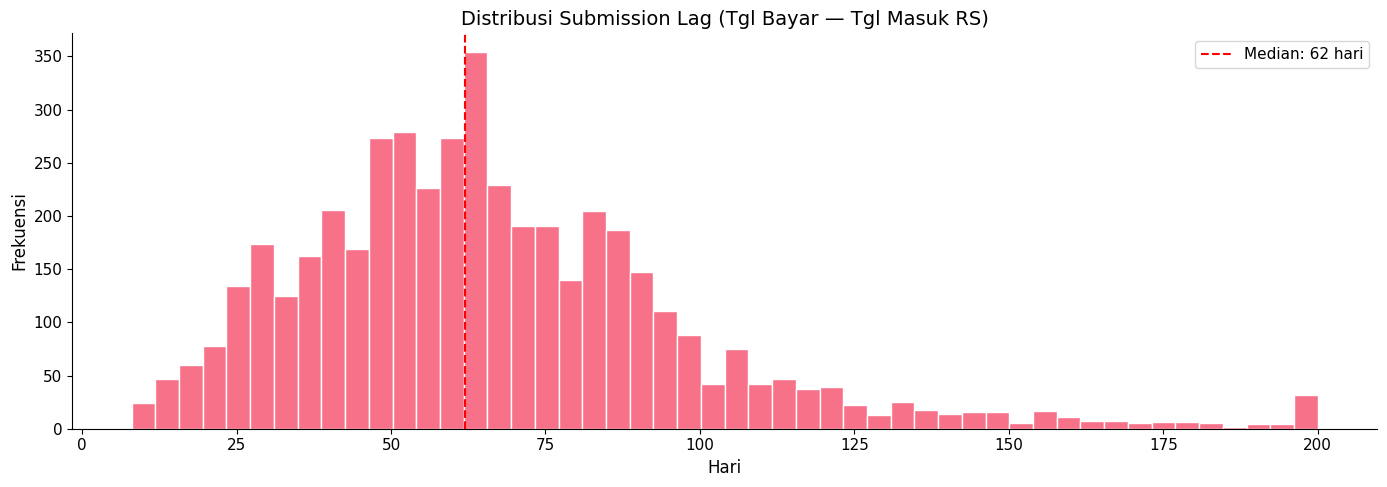

In [22]:
# Submission Lag = Tgl Bayar - Tgl Masuk RS (end-to-end delay)
df['Submission_Lag'] = (df['Tanggal Pembayaran Klaim'] - df['Tanggal Pasien Masuk RS']).dt.days

valid_lag = df[df['Submission_Lag'].notna() & (df['Submission_Lag'] >= 0)]
print(f"📊 Submission Lag Statistics:")
print(f"   Mean: {valid_lag['Submission_Lag'].mean():.0f} hari")
print(f"   Median: {valid_lag['Submission_Lag'].median():.0f} hari")
print(f"   Min: {valid_lag['Submission_Lag'].min():.0f} | Max: {valid_lag['Submission_Lag'].max():.0f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(valid_lag['Submission_Lag'].clip(0, 200), bins=50, color=COLORS[0], edgecolor='white')
ax.axvline(valid_lag['Submission_Lag'].median(), color='red', linestyle='--',
           label=f'Median: {valid_lag["Submission_Lag"].median():.0f} hari')
ax.set_title('Distribusi Submission Lag (Tgl Bayar — Tgl Masuk RS)')
ax.set_xlabel('Hari')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Lag Time: Indonesia vs Luar Negeri

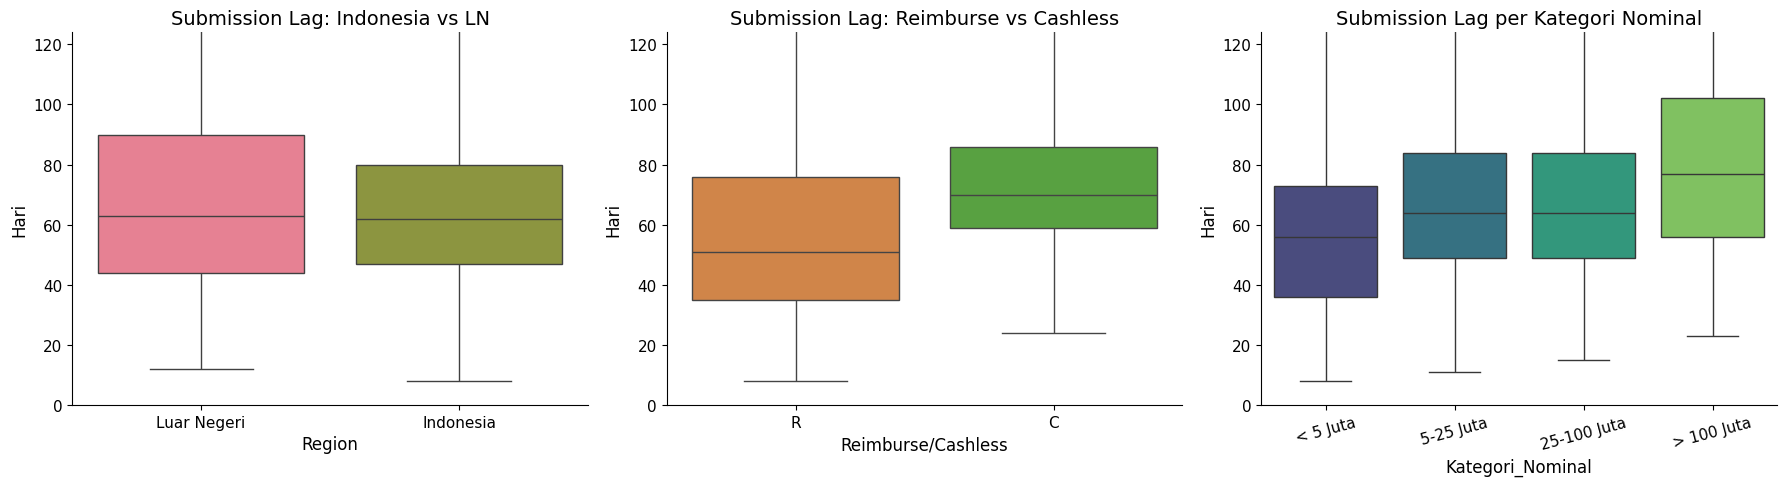


📊 Lag by Region:
             mean  median   std
Region                         
Indonesia    63.5    62.0  27.2
Luar Negeri  73.7    63.0  44.2

📊 Lag by Tipe Pembayaran:
                    mean  median   std
Reimburse/Cashless                    
C                   74.4    70.0  20.5
R                   61.5    51.0  40.0


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Indonesia vs LN
sns.boxplot(data=valid_lag, x='Region', y='Submission_Lag', palette=[COLORS[0], COLORS[3]], ax=axes[0])
axes[0].set_title('Submission Lag: Indonesia vs LN')
axes[0].set_ylabel('Hari')
axes[0].set_ylim(0, valid_lag['Submission_Lag'].quantile(0.95))

# Reimburse vs Cashless
sns.boxplot(data=valid_lag, x='Reimburse/Cashless', y='Submission_Lag',
            palette=[COLORS[1], COLORS[4]], ax=axes[1])
axes[1].set_title('Submission Lag: Reimburse vs Cashless')
axes[1].set_ylabel('Hari')
axes[1].set_ylim(0, valid_lag['Submission_Lag'].quantile(0.95))

# Per Kategori Nominal
sns.boxplot(data=valid_lag, x='Kategori_Nominal', y='Submission_Lag',
            order=kat_order, palette='viridis', ax=axes[2])
axes[2].set_title('Submission Lag per Kategori Nominal')
axes[2].set_ylabel('Hari')
axes[2].set_ylim(0, valid_lag['Submission_Lag'].quantile(0.95))
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Summary stats
lag_summary = valid_lag.groupby('Region')['Submission_Lag'].agg(['mean','median','std']).round(1)
print("\n📊 Lag by Region:")
print(lag_summary.to_string())

lag_type = valid_lag.groupby('Reimburse/Cashless')['Submission_Lag'].agg(['mean','median','std']).round(1)
print("\n📊 Lag by Tipe Pembayaran:")
print(lag_type.to_string())

---
## Phase 6: Deep Dive Rasio Coverage (Product Repricing)

### 6.1 Klaim Under-covered (Rasio Coverage < 0.8)

⚠️  Klaim Under-covered (Rasio < 0.8): 713 (15.4%)
   Nasabah bayar sendiri (gap) total: Rp 15.8 Miliar


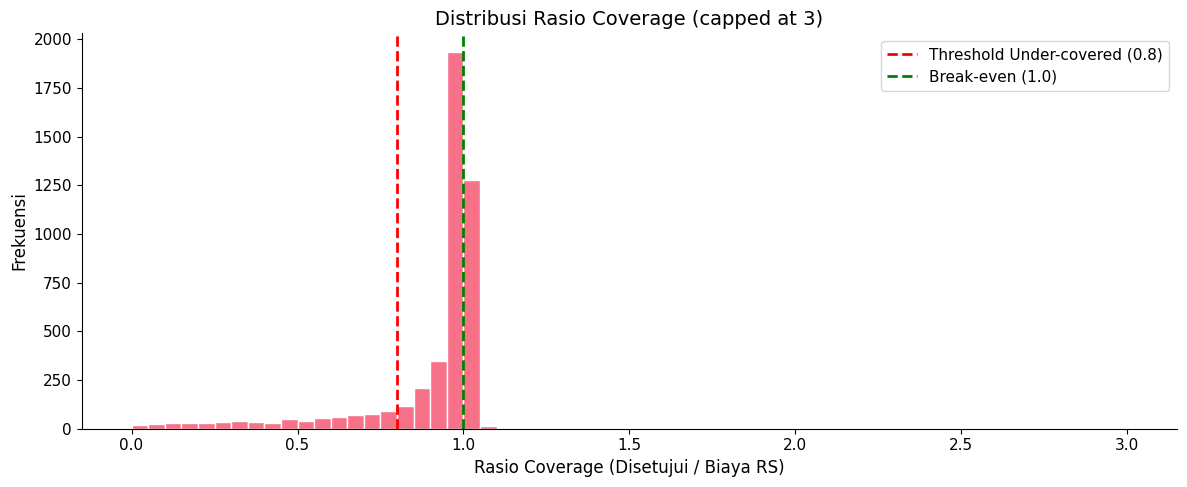

In [24]:
undercov = df[df['Rasio_Coverage'] < 0.8].copy()
overcov = df[df['Rasio_Coverage'] >= 0.8].copy()

print(f"⚠️  Klaim Under-covered (Rasio < 0.8): {len(undercov):,} ({len(undercov)/len(df)*100:.1f}%)")
print(f"   Nasabah bayar sendiri (gap) total: Rp {undercov['Selisih_Klaim'].clip(upper=0).abs().sum()/1e9:.1f} Miliar")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['Rasio_Coverage'].clip(0, 3).dropna(), bins=60, color=COLORS[0], edgecolor='white')
ax.axvline(0.8, color='red', linestyle='--', linewidth=2, label='Threshold Under-covered (0.8)')
ax.axvline(1.0, color='green', linestyle='--', linewidth=2, label='Break-even (1.0)')
ax.set_title('Distribusi Rasio Coverage (capped at 3)')
ax.set_xlabel('Rasio Coverage (Disetujui / Biaya RS)')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Under-covered per Plan Code

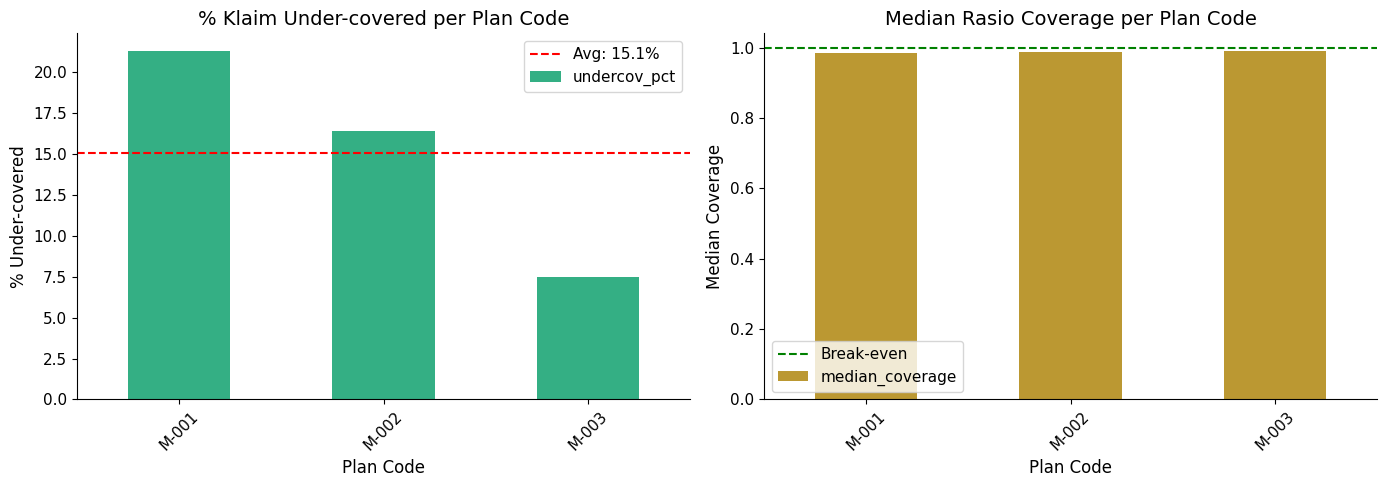

📋 Plan Code dengan limit paling 'usang' (highest % under-covered):
   M-001: 21.3% under-covered, median coverage 0.99
   M-002: 16.4% under-covered, median coverage 0.99
   M-003: 7.5% under-covered, median coverage 0.99


In [25]:
plan_coverage = df.groupby('Plan Code').agg(
    total_klaim=('Claim ID', 'count'),
    undercov_count=('Rasio_Coverage', lambda x: (x < 0.8).sum()),
    median_coverage=('Rasio_Coverage', 'median'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()
plan_coverage['undercov_pct'] = plan_coverage['undercov_count'] / plan_coverage['total_klaim'] * 100
plan_coverage = plan_coverage.sort_values('undercov_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plan_coverage.set_index('Plan Code')['undercov_pct'].plot(kind='bar', ax=axes[0], color=COLORS[5])
axes[0].set_title('% Klaim Under-covered per Plan Code')
axes[0].set_ylabel('% Under-covered')
axes[0].axhline(plan_coverage['undercov_pct'].mean(), color='red', linestyle='--',
                label=f'Avg: {plan_coverage["undercov_pct"].mean():.1f}%')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

plan_coverage.set_index('Plan Code')['median_coverage'].plot(kind='bar', ax=axes[1], color=COLORS[2])
axes[1].set_title('Median Rasio Coverage per Plan Code')
axes[1].set_ylabel('Median Coverage')
axes[1].axhline(1.0, color='green', linestyle='--', label='Break-even')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📋 Plan Code dengan limit paling 'usang' (highest % under-covered):")
for _, row in plan_coverage.head(5).iterrows():
    print(f"   {row['Plan Code']}: {row['undercov_pct']:.1f}% under-covered, median coverage {row['median_coverage']:.2f}")

### 6.3 Coverage Gap per ICD Group

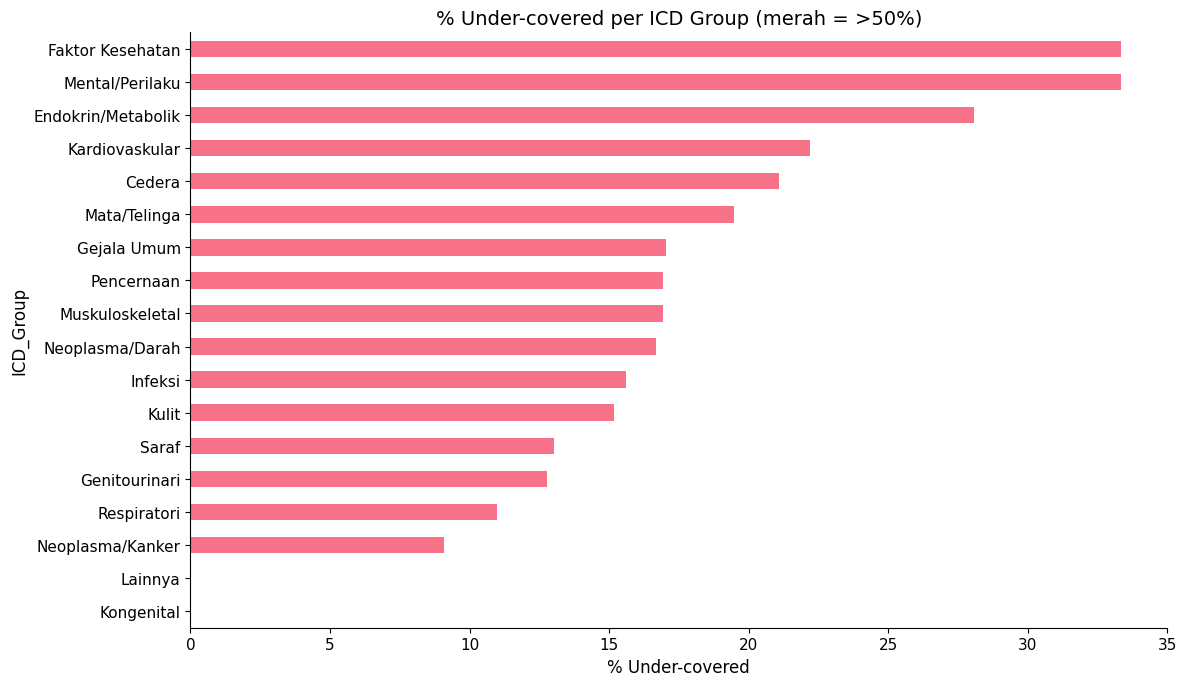

In [26]:
icd_coverage = df.groupby('ICD_Group').agg(
    total_klaim=('Claim ID', 'count'),
    undercov_pct=('Rasio_Coverage', lambda x: (x < 0.8).mean() * 100),
    median_coverage=('Rasio_Coverage', 'median'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean')
).sort_values('undercov_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['red' if v > 50 else COLORS[0] for v in icd_coverage['undercov_pct']]
icd_coverage['undercov_pct'].plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('% Under-covered per ICD Group (merah = >50%)')
ax.set_xlabel('% Under-covered')
plt.tight_layout()
plt.show()

### 6.4 Coverage Gap: Indonesia vs Luar Negeri

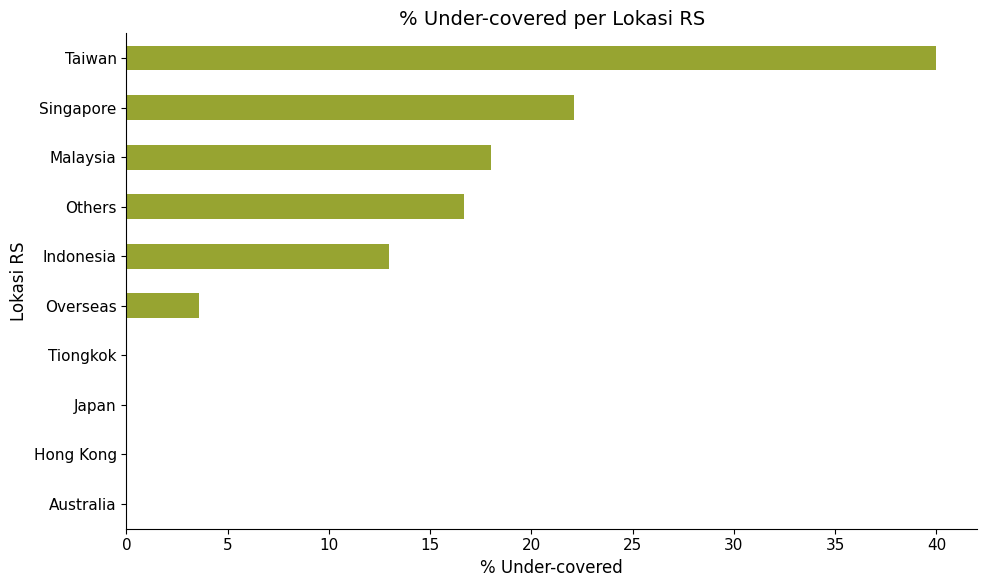

💡 Under-covered comparison:
   Australia: 0.0% under-covered, median coverage 1.00
   Hong Kong: 0.0% under-covered, median coverage 1.00
   Japan: 0.0% under-covered, median coverage 0.98
   Tiongkok: 0.0% under-covered, median coverage 0.84
   Overseas: 3.6% under-covered, median coverage 1.05
   Indonesia: 13.0% under-covered, median coverage 0.99
   Others: 16.7% under-covered, median coverage 0.98
   Malaysia: 18.0% under-covered, median coverage 0.97
   Singapore: 22.1% under-covered, median coverage 0.98
   Taiwan: 40.0% under-covered, median coverage 0.87


In [27]:
region_coverage = df.groupby('Lokasi RS').agg(
    total=('Claim ID', 'count'),
    undercov_pct=('Rasio_Coverage', lambda x: (x < 0.8).mean() * 100),
    median_cov=('Rasio_Coverage', 'median')
).sort_values('undercov_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
region_coverage['undercov_pct'].plot(kind='barh', ax=ax, color=COLORS[3])
ax.set_title('% Under-covered per Lokasi RS')
ax.set_xlabel('% Under-covered')
plt.tight_layout()
plt.show()

print("💡 Under-covered comparison:")
for loc, row in region_coverage.iterrows():
    print(f"   {loc}: {row['undercov_pct']:.1f}% under-covered, median coverage {row['median_cov']:.2f}")

### 6.5 Tren Rasio Coverage per Bulan (Inflasi Medis)

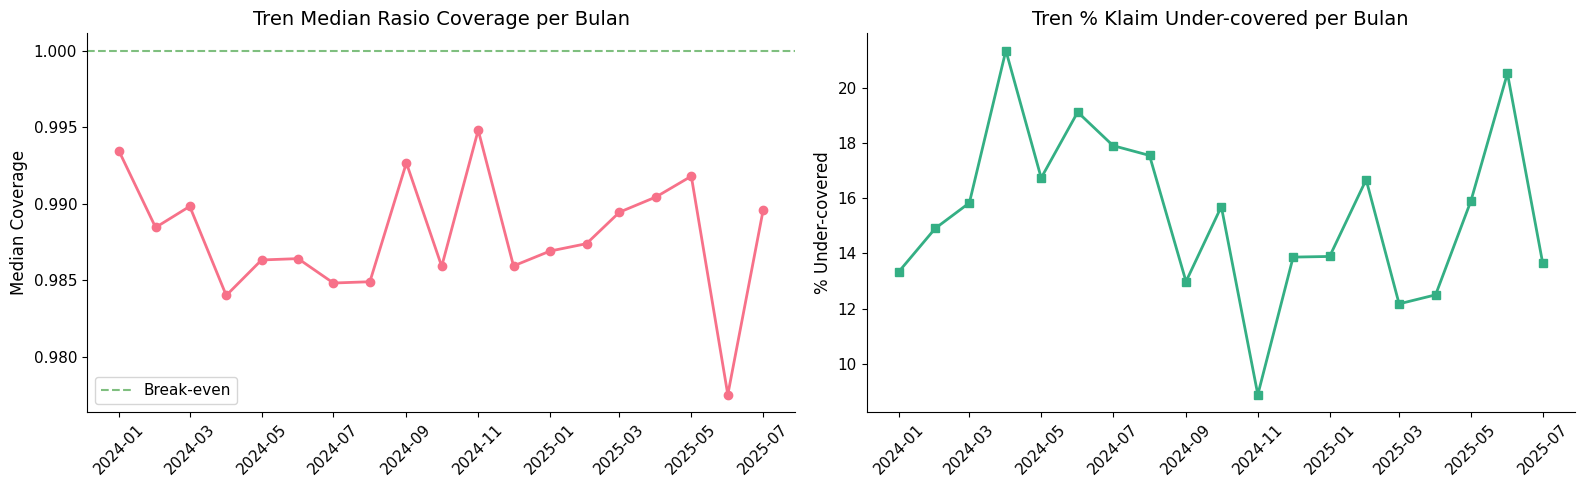

In [28]:
monthly_coverage = df.groupby('Bulan_dt').agg(
    median_coverage=('Rasio_Coverage', 'median'),
    undercov_pct=('Rasio_Coverage', lambda x: (x < 0.8).mean() * 100)
).reset_index().dropna(subset=['Bulan_dt'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_coverage['Bulan_dt'], monthly_coverage['median_coverage'],
             marker='o', color=COLORS[0], linewidth=2)
axes[0].axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Break-even')
axes[0].set_title('Tren Median Rasio Coverage per Bulan')
axes[0].set_ylabel('Median Coverage')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_coverage['Bulan_dt'], monthly_coverage['undercov_pct'],
             marker='s', color=COLORS[5], linewidth=2)
axes[1].set_title('Tren % Klaim Under-covered per Bulan')
axes[1].set_ylabel('% Under-covered')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Phase 7: Fraud Detection Sederhana

### 7.1 Split Bill Detection
Klaim dari polis sama, RS sama, < 3 hari, diagnosis mirip

In [29]:
df_sorted = df.sort_values(['Nomor Polis', 'Lokasi RS', 'Tanggal Pasien Masuk RS'])
df_sorted['prev_polis'] = df_sorted['Nomor Polis'].shift(1)
df_sorted['prev_rs'] = df_sorted['Lokasi RS'].shift(1)
df_sorted['prev_date'] = df_sorted['Tanggal Pasien Masuk RS'].shift(1)
df_sorted['prev_icd'] = df_sorted['ICD Diagnosis'].shift(1)

df_sorted['gap_days'] = (df_sorted['Tanggal Pasien Masuk RS'] - df_sorted['prev_date']).dt.days

split_bill = df_sorted[
    (df_sorted['Nomor Polis'] == df_sorted['prev_polis']) &
    (df_sorted['Lokasi RS'] == df_sorted['prev_rs']) &
    (df_sorted['gap_days'] >= 0) & (df_sorted['gap_days'] <= 3) &
    (df_sorted['ICD Diagnosis'] == df_sorted['prev_icd'])
]

print(f"🚩 Potensi Split Bill: {len(split_bill)} klaim")
if len(split_bill) > 0:
    print("\nSample kasus:")
    display(split_bill[['Claim ID','Nomor Polis','Lokasi RS','ICD Diagnosis',
                        'Tanggal Pasien Masuk RS','Nominal Klaim Yang Disetujui','gap_days']].head(10))

🚩 Potensi Split Bill: 859 klaim

Sample kasus:


,Claim ID,Nomor Polis,Lokasi RS,ICD Diagnosis,Tanggal Pasien Masuk RS,Nominal Klaim Yang Disetujui,gap_days
2650,C-3447-M,POL-0010,Singapore,K31.7,2024-01-19,1723747.00,1.0
2523,C-3301-M,POL-0033,Indonesia,H26,2024-09-05,845000.00,1.0
4076,C-5071-M,POL-0040,Indonesia,H26,2024-01-16,475000.00,1.0
2097,C-2706-M,POL-0060,Indonesia,L72.0,2024-07-04,565000.00,2.0
27,C-0034-M,POL-0071,Malaysia,C56,2025-03-04,15882920.84,1.0
36,C-0043-M,POL-0071,Malaysia,C56,2025-03-28,16385256.95,1.0
729,C-0954-M,POL-0097,Indonesia,C34,2024-07-16,3210000.00,1.0
728,C-0953-M,POL-0097,Indonesia,C34,2024-07-17,3379000.00,1.0
727,C-0952-M,POL-0097,Indonesia,C34,2024-07-19,4401170.00,2.0
726,C-0951-M,POL-0097,Indonesia,C34,2024-07-22,4544500.00,3.0


### 7.2 Repeat Pattern Anomali
Polis dengan klaim terlalu reguler (klaim sangat frequent)

In [30]:
polis_freq = df.groupby('Nomor Polis').agg(
    total_klaim=('Claim ID', 'count'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    date_range=('Tanggal Pasien Masuk RS', lambda x: (x.max() - x.min()).days),
    unique_rs=('Lokasi RS', 'nunique'),
    unique_diag=('ICD Diagnosis', 'nunique')
).reset_index()

# Polis dengan klaim > 10 & rata-rata gap < 14 hari
polis_freq['avg_gap'] = polis_freq['date_range'] / (polis_freq['total_klaim'] - 1).clip(1)
repeat_anomaly = polis_freq[(polis_freq['total_klaim'] > 10) & (polis_freq['avg_gap'] < 14)]
repeat_anomaly = repeat_anomaly.sort_values('total_klaim', ascending=False)

print(f"🚩 Polis dengan pola repeat anomali (>10 klaim, avg gap <14 hari): {len(repeat_anomaly)}")
if len(repeat_anomaly) > 0:
    display(repeat_anomaly.head(10))

🚩 Polis dengan pola repeat anomali (>10 klaim, avg gap <14 hari): 14


,Nomor Polis,total_klaim,total_nominal,date_range,unique_rs,unique_diag,avg_gap
607,POL-2078,222,1.728387e+09,576,1,13,2.606335
647,POL-2200,167,3.951283e+08,576,1,5,3.469880
618,POL-2111,91,5.855674e+08,290,3,5,3.222222
683,POL-2329,89,1.892651e+09,553,2,6,6.284091
898,POL-3045,64,9.616814e+07,440,1,4,6.984127
270,POL-0856,45,5.970106e+09,565,2,7,12.840909
839,POL-2878,41,2.000302e+09,492,1,2,12.300000
904,POL-3075,21,7.291950e+07,28,1,1,1.400000
291,POL-0935,20,1.613380e+09,219,2,9,11.526316
287,POL-0921,16,4.808994e+08,195,1,4,13.000000


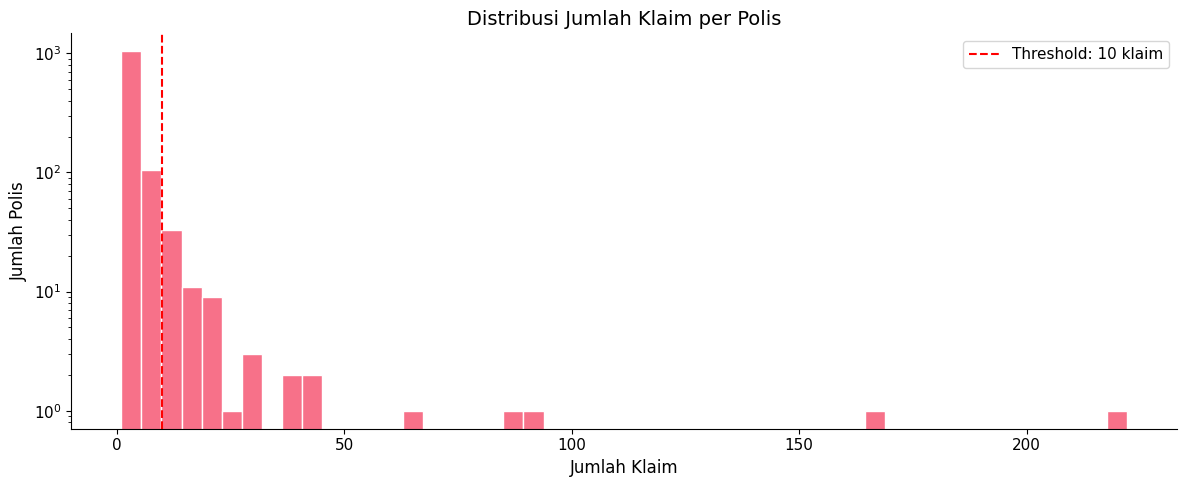

In [31]:
# Distribusi frekuensi klaim per polis
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(polis_freq['total_klaim'], bins=50, color=COLORS[0], edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='Threshold: 10 klaim')
ax.set_title('Distribusi Jumlah Klaim per Polis')
ax.set_xlabel('Jumlah Klaim')
ax.set_ylabel('Jumlah Polis')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### 7.3 Outlier per Diagnosis
Klaim yang jauh di atas rata-rata untuk diagnosis yang sama

In [32]:
# Z-score per diagnosis group
diag_stats = df.groupby('ICD Diagnosis')['Nominal Klaim Yang Disetujui'].agg(['mean', 'std', 'count'])
diag_stats.columns = ['diag_mean', 'diag_std', 'diag_count']
df_outlier = df.merge(diag_stats, left_on='ICD Diagnosis', right_index=True)
df_outlier['z_score'] = (df_outlier['Nominal Klaim Yang Disetujui'] - df_outlier['diag_mean']) / df_outlier['diag_std'].clip(1)

# Klaim dengan z-score > 3 dan diagnosis punya cukup sample (>5)
outliers = df_outlier[(df_outlier['z_score'] > 3) & (df_outlier['diag_count'] > 5)]
outliers = outliers.sort_values('z_score', ascending=False)

print(f"🚩 Outlier per Diagnosis (Z > 3, min 5 sample): {len(outliers)} klaim")
if len(outliers) > 0:
    display(outliers[['Claim ID','Nomor Polis','ICD Diagnosis','ICD Description',
                      'Nominal Klaim Yang Disetujui','diag_mean','z_score','Lokasi RS']].head(15))

🚩 Outlier per Diagnosis (Z > 3, min 5 sample): 58 klaim


,Claim ID,Nomor Polis,ICD Diagnosis,ICD Description,Nominal Klaim Yang Disetujui,diag_mean,z_score,Lokasi RS
2858,C-3682-M,POL-0660,N18.0,END-STAGE RENAL DISEASE,8.434153e+08,5.881692e+06,16.868714,Indonesia
2990,C-3822-M,POL-0302,N18.5,"CHRONIC KIDNEY DISEASE, STAGE 5",7.254725e+08,1.337219e+07,8.846315,Indonesia
3347,C-4218-M,POL-1939,N23,UNSPECIFIED RENAL COLIC,1.720725e+08,5.948245e+06,7.771315,Indonesia
1871,C-2424-M,POL-3964,C25,MALIGNANT NEOPLASM OF PANCREAS,1.259901e+09,8.573493e+07,6.753816,Singapore
1927,C-2491-M,POL-2740,H26,OTHER CATARACT,2.866387e+08,2.135094e+07,6.672261,Singapore
322,C-0449-M,POL-2551,I25.1,CORONARY ATRIAL DISEASES (CAD),2.197500e+09,1.442235e+08,6.129899,Singapore
1211,C-1501-M,POL-2111,H35.3,Degeneration of macula and posterior pole,2.746705e+08,2.315477e+07,6.090029,Singapore
1008,C-1291-M,POL-2850,H26,OTHER CATARACT,2.579008e+08,2.135094e+07,5.949474,Singapore
2444,C-3217-M,POL-2666,R10,ABDOMINAL AND PELVIC PAIN,2.510858e+08,2.140710e+07,5.465291,Indonesia
365,C-0501-M,POL-2535,I25.1,CORONARY ATRIAL DISEASES (CAD),1.938410e+09,1.442235e+08,5.356407,Singapore


### 7.4 Tabel Flag: Polis yang Perlu Audit

In [33]:
# Gabungkan semua flag
flag_split = set(split_bill['Nomor Polis'].tolist()) if len(split_bill) > 0 else set()
flag_repeat = set(repeat_anomaly['Nomor Polis'].tolist()) if len(repeat_anomaly) > 0 else set()
flag_outlier = set(outliers['Nomor Polis'].tolist()) if len(outliers) > 0 else set()

all_flagged = flag_split | flag_repeat | flag_outlier

flagged_df = pd.DataFrame({
    'Nomor Polis': list(all_flagged)
})
flagged_df['Split_Bill'] = flagged_df['Nomor Polis'].isin(flag_split)
flagged_df['Repeat_Anomaly'] = flagged_df['Nomor Polis'].isin(flag_repeat)
flagged_df['Nominal_Outlier'] = flagged_df['Nomor Polis'].isin(flag_outlier)
flagged_df['Total_Flags'] = flagged_df[['Split_Bill','Repeat_Anomaly','Nominal_Outlier']].sum(axis=1)

# Enrich with polis stats
flagged_df = flagged_df.merge(polis_freq[['Nomor Polis','total_klaim','total_nominal']], on='Nomor Polis', how='left')
flagged_df = flagged_df.sort_values('Total_Flags', ascending=False)

print(f"🔍 Total polis yang ter-flag: {len(flagged_df)}")
print(f"   Split bill: {len(flag_split)} | Repeat anomaly: {len(flag_repeat)} | Nominal outlier: {len(flag_outlier)}")
print(f"\n📋 Polis dengan multiple flags (perlu prioritas audit):")
multi_flag = flagged_df[flagged_df['Total_Flags'] >= 2]
if len(multi_flag) > 0:
    display(multi_flag)
else:
    print("   Tidak ada polis dengan lebih dari 1 flag")

display(flagged_df.head(20))

🔍 Total polis yang ter-flag: 333
   Split bill: 304 | Repeat anomaly: 14 | Nominal outlier: 54

📋 Polis dengan multiple flags (perlu prioritas audit):


,Nomor Polis,Split_Bill,Repeat_Anomaly,Nominal_Outlier,Total_Flags,total_klaim,total_nominal
16,POL-0856,True,True,True,3,45,5.970106e+09
206,POL-2878,True,True,True,3,41,2.000302e+09
80,POL-2111,True,True,True,3,91,5.855674e+08
120,POL-1255,True,True,True,3,12,8.160191e+08
194,POL-2200,True,True,True,3,167,3.951283e+08
331,POL-1037,True,False,True,2,12,2.088016e+09
322,POL-0478,True,False,True,2,4,1.600931e+08
48,POL-0388,True,False,True,2,8,1.518692e+09
132,POL-0881,True,False,True,2,2,1.079742e+08
50,POL-0957,True,False,True,2,8,1.497430e+09


,Nomor Polis,Split_Bill,Repeat_Anomaly,Nominal_Outlier,Total_Flags,total_klaim,total_nominal
16,POL-0856,True,True,True,3,45,5.970106e+09
206,POL-2878,True,True,True,3,41,2.000302e+09
80,POL-2111,True,True,True,3,91,5.855674e+08
120,POL-1255,True,True,True,3,12,8.160191e+08
194,POL-2200,True,True,True,3,167,3.951283e+08
331,POL-1037,True,False,True,2,12,2.088016e+09
322,POL-0478,True,False,True,2,4,1.600931e+08
48,POL-0388,True,False,True,2,8,1.518692e+09
132,POL-0881,True,False,True,2,2,1.079742e+08
50,POL-0957,True,False,True,2,8,1.497430e+09


---
## Phase 8: Summary Executive & Rekomendasi Bisnis

### 8.1 Dashboard Key Metrics

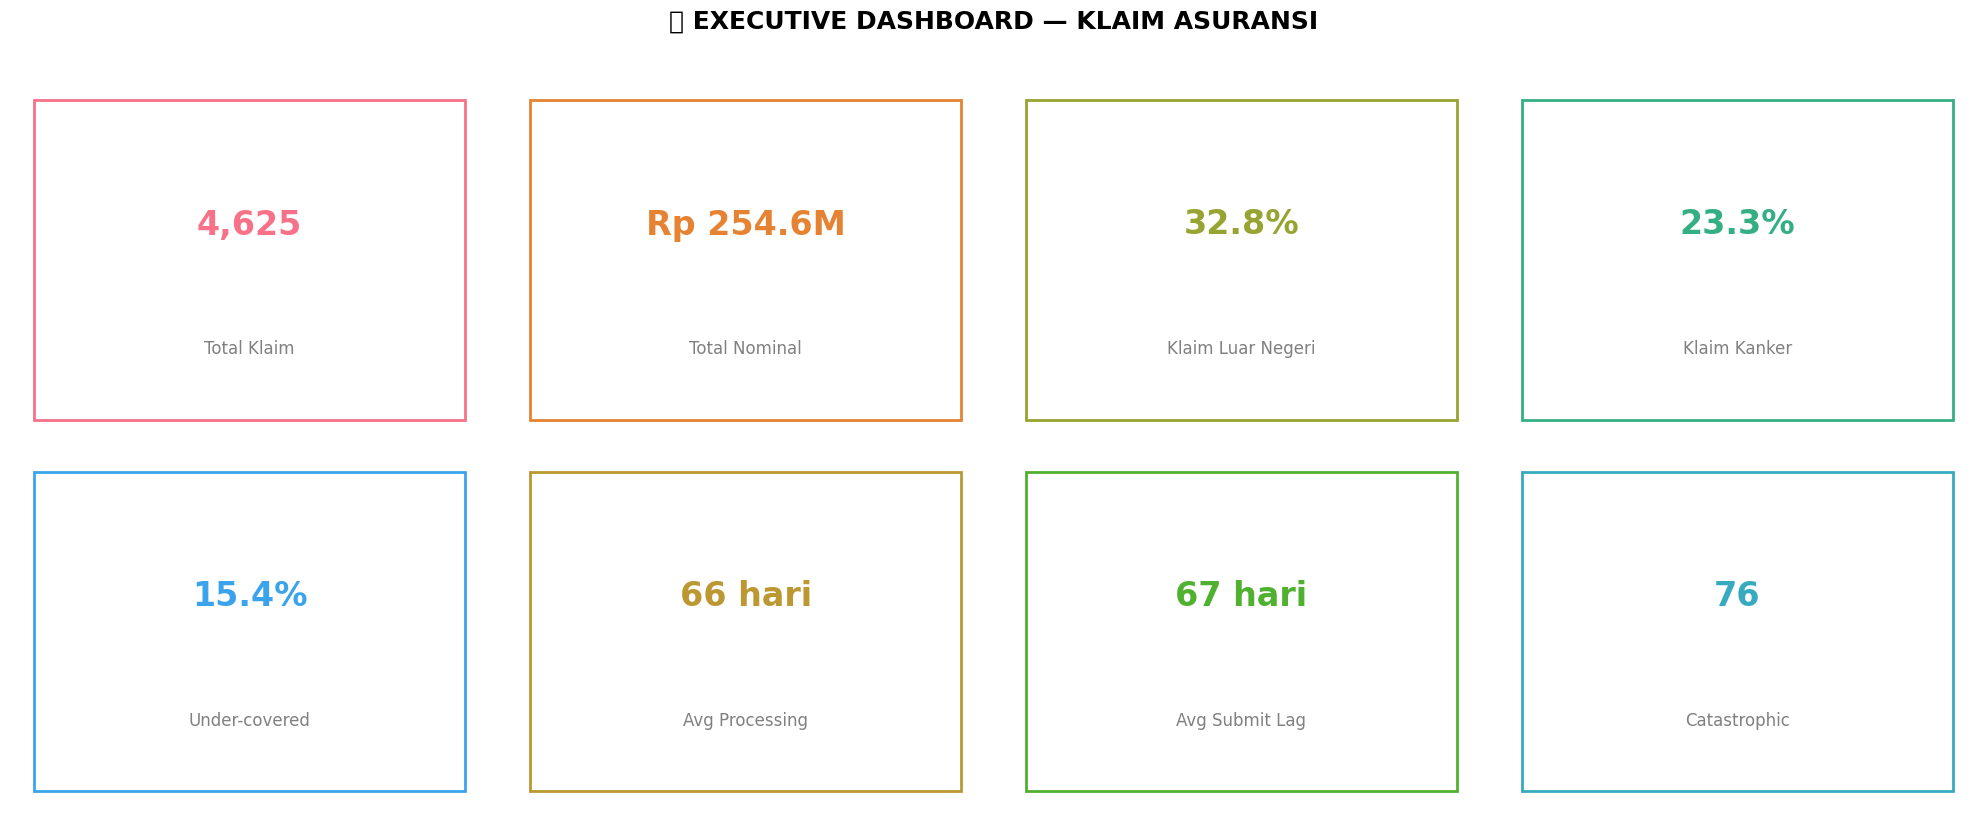

In [34]:
total_klaim = len(df)
total_nominal = df['Nominal Klaim Yang Disetujui'].sum()
total_biaya = df['Nominal Biaya RS Yang Terjadi'].sum()
pct_overseas = df['Is_Overseas'].mean() * 100
pct_cancer = df['Is_Cancer'].mean() * 100
pct_undercov = (df['Rasio_Coverage'] < 0.8).mean() * 100
avg_proc_days = df['Processing_Days'].mean()
avg_submit_lag = valid_lag['Submission_Lag'].mean()
n_catastrophic = df['Is_Catastrophic'].sum()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('📊 EXECUTIVE DASHBOARD — KLAIM ASURANSI', fontsize=18, fontweight='bold', y=1.02)

metrics = [
    ('Total Klaim', f'{total_klaim:,}', COLORS[0]),
    ('Total Nominal', f'Rp {total_nominal/1e9:.1f}M', COLORS[1]),
    ('Klaim Luar Negeri', f'{pct_overseas:.1f}%', COLORS[3]),
    ('Klaim Kanker', f'{pct_cancer:.1f}%', COLORS[5]),
    ('Under-covered', f'{pct_undercov:.1f}%', COLORS[8]),
    ('Avg Processing', f'{avg_proc_days:.0f} hari', COLORS[2]),
    ('Avg Submit Lag', f'{avg_submit_lag:.0f} hari', COLORS[4]),
    ('Catastrophic', f'{n_catastrophic}', COLORS[7]),
]

for ax, (label, value, color) in zip(axes.flat, metrics):
    ax.text(0.5, 0.6, value, transform=ax.transAxes, fontsize=24,
            fontweight='bold', ha='center', va='center', color=color)
    ax.text(0.5, 0.25, label, transform=ax.transAxes, fontsize=12,
            ha='center', va='center', color='gray')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False,
                                edgecolor=color, linewidth=2, transform=ax.transAxes))

plt.tight_layout()
plt.show()

### 8.2 Insight Summary per Phase

#### Phase 1 — Medical Tourism
- Klaim luar negeri meskipun jumlahnya kecil, memiliki rata-rata biaya yang jauh lebih tinggi
- Singapore dan Malaysia adalah destinasi utama medical tourism
- Jakarta mendominasi sebagai domisili pengirim pasien ke luar negeri
- Beberapa diagnosis memiliki biaya 2-5x lebih mahal di luar negeri

#### Phase 2 — Kanker sebagai Cost Driver
- Klaim kanker menghabiskan porsi signifikan dari total biaya
- Distribusi biaya kanker sangat long-tail: sedikit polis menghabiskan mayoritas biaya
- Coverage ratio kanker menunjukkan gap yang perlu diperhatikan

#### Phase 3 — Efisiensi Pemrosesan
- Terdapat klaim kecil yang membutuhkan waktu processing disproportional
- Klaim luar negeri cenderung memiliki processing time lebih panjang

#### Phase 4 — Seasonality
- Beberapa kelompok penyakit menunjukkan pola musiman
- Tren klaim kanker perlu dipantau untuk proyeksi biaya

#### Phase 5 — Lag Time
- Submission lag bervariasi signifikan antara reimburse vs cashless
- Klaim luar negeri memiliki end-to-end delay yang lebih panjang

#### Phase 6 — Coverage Gap
- Beberapa plan code menunjukkan limit yang sudah tidak memadai
- Tren coverage yang menurun mengindikasikan inflasi medis

#### Phase 7 — Fraud Detection
- Teridentifikasi polis-polis yang perlu audit berdasarkan pola split bill, repeat anomaly, dan outlier nominal

### 8.3 Rekomendasi Bisnis Actionable

#### 🏥 Cost Containment
1. **Managed Care Network LN**: Negosiasi tarif dengan RS mitra di Singapore/Malaysia untuk diagnosis-diagnosis yang sering dirujuk ke luar negeri
2. **Second Opinion Program**: Untuk klaim >100 Juta, wajibkan second opinion sebelum approval
3. **Cancer Case Management**: Assign case manager khusus untuk polis kanker high-cost untuk monitoring efektivitas pengobatan

#### 💰 Product Repricing
1. **Plan Limit Review**: Plan code dengan % under-covered tertinggi perlu segera di-review limitnya
2. **Cancer Rider**: Pertimbangkan rider khusus kanker dengan limit terpisah mengingat biaya kanker yang sangat tinggi
3. **Inflation Adjustment**: Sesuaikan limit tahunan berdasarkan tren inflasi medis yang terlihat dari menurunnya rasio coverage

#### 🔍 Fraud Audit
1. **Prioritas Audit**: Fokuskan audit pada polis dengan multiple flags (split bill + repeat anomaly + outlier)
2. **Rule-based Alert**: Implementasikan rules otomatis untuk mendeteksi split bill pada saat submission klaim
3. **Peer Review**: Klaim dengan z-score > 3 untuk diagnosis tertentu perlu peer review medis

#### ⚙️ Ops Efficiency
1. **Fast Track Small Claims**: Klaim < 5 Juta seharusnya bisa diproses < 7 hari dengan auto-adjudication
2. **Digital Submission LN**: Percepat proses klaim luar negeri dengan digitalisasi dokumen
3. **SLA Monitoring**: Dashboard real-time untuk processing days per kategori dan lokasi

In [35]:
print("=" * 80)
print("🏁 DEEP DIVE INSIGHT NOTEBOOK — SELESAI")
print("=" * 80)
print(f"\nTotal klaim dianalisis: {total_klaim:,}")
print(f"Total nominal: Rp {total_nominal/1e9:.1f} Miliar")
print(f"Polis ter-flag untuk audit: {len(flagged_df)}")
print(f"\nNotebook ini mencakup 9 phase analisis mendalam.")
print("Silakan review insight dan rekomendasi di atas untuk tindak lanjut bisnis.")

🏁 DEEP DIVE INSIGHT NOTEBOOK — SELESAI

Total klaim dianalisis: 4,625
Total nominal: Rp 254.6 Miliar
Polis ter-flag untuk audit: 333

Notebook ini mencakup 9 phase analisis mendalam.
Silakan review insight dan rekomendasi di atas untuk tindak lanjut bisnis.


---
## Phase 9: Analisis Dampak Nilai Tukar (FX Impact)
### Klaim LN (Singapore/Malaysia/Others) × FX Rate SGD/MYR/USD terhadap IDR

In [36]:
# ── Load FX data ──────────────────────────────────────────────────
def parse_id_num(s):
    """Parse angka format Indonesia: '16.675,0' → 16675.0"""
    s = str(s).strip()
    if s in ('', '-', 'nan', 'NaN'): return np.nan
    s = s.replace('.', '').replace(',', '.')
    try: return float(s)
    except: return np.nan

def load_fx(path, currency_name):
    df_fx = pd.read_csv(path)
    df_fx.columns = df_fx.columns.str.strip()
    df_fx['date'] = pd.to_datetime(df_fx['Tanggal'], format='%d/%m/%Y', dayfirst=True)
    df_fx['rate'] = df_fx['Terakhir'].apply(parse_id_num)
    df_fx['currency'] = currency_name
    return df_fx[['date','rate','currency']].dropna(subset=['rate']).sort_values('date')

fx_sgd = load_fx('dataset/Data Historis SGD_IDR.csv', 'SGD')
fx_myr = load_fx('dataset/Data Historis MYR_IDR.csv', 'MYR')
fx_usd = load_fx('dataset/Data Historis USD_IDR.csv', 'USD')

for name, df_fx in [('SGD/IDR', fx_sgd), ('MYR/IDR', fx_myr), ('USD/IDR', fx_usd)]:
    print(f'{name}: {len(df_fx)} hari data | '
          f'{df_fx["date"].min().date()} → {df_fx["date"].max().date()} | '
          f'rate: {df_fx["rate"].min():.0f} – {df_fx["rate"].max():.0f}')


SGD/IDR: 24 hari data | 2026-01-14 → 2026-02-13 | rate: 13093 – 13333
MYR/IDR: 514 hari data | 2024-01-15 → 2026-01-01 | rate: 3256 – 4142
USD/IDR: 514 hari data | 2024-01-15 → 2026-01-01 | rate: 15095 – 16870


### 9.1 Setup FX Lookup & Enrich Data Klaim dengan FX Rate

In [37]:
# Mapping lokasi RS → mata uang
def lokasi_to_currency(lokasi):
    if pd.isna(lokasi): return 'IDR'
    l = str(lokasi).strip()
    if l == 'Singapore': return 'SGD'
    elif l == 'Malaysia': return 'MYR'
    elif l == 'Indonesia': return 'IDR'
    else: return 'USD'  # Taiwan, HK, Japan, Overseas, Others

df['currency_rs'] = df['Lokasi RS'].apply(lokasi_to_currency)

# Bangun daily FX lookup dengan forward-fill untuk hari libur
date_range = pd.date_range(
    start=df['Tanggal Pasien Masuk RS'].min(),
    end=df['Tanggal Pasien Masuk RS'].max(),
    freq='D'
)
date_df = pd.DataFrame({'date': date_range})

def build_lookup(fx_df, date_df):
    m = date_df.merge(fx_df[['date','rate']], on='date', how='left')
    m['rate'] = m['rate'].ffill().bfill()
    return m.set_index('date')['rate']

sgd_lkp = build_lookup(fx_sgd, date_df)
myr_lkp = build_lookup(fx_myr, date_df)
usd_lkp = build_lookup(fx_usd, date_df)

def get_fx(row):
    d = row['Tanggal Pasien Masuk RS']
    c = row['currency_rs']
    if pd.isna(d) or c == 'IDR': return np.nan
    try:
        if c == 'SGD': return sgd_lkp.loc[d]
        elif c == 'MYR': return myr_lkp.loc[d]
        elif c == 'USD': return usd_lkp.loc[d]
    except: return np.nan

df['fx_rate_masuk'] = df.apply(get_fx, axis=1)

# Estimasi biaya dalam mata uang asing
df['nominal_foreign'] = np.where(
    df['currency_rs'] != 'IDR',
    df['Nominal Klaim Yang Disetujui'] / df['fx_rate_masuk'],
    np.nan
)

print('Breakdown currency:')
print(df['currency_rs'].value_counts().to_string())
print(f'\nKlaim LN dengan FX rate: {df["fx_rate_masuk"].notna().sum()}')


Breakdown currency:
currency_rs
IDR    3107
SGD    1019
MYR     456
USD      43

Klaim LN dengan FX rate: 499


### 9.2 Tren FX Rate & Total Nominal Klaim per Bulan

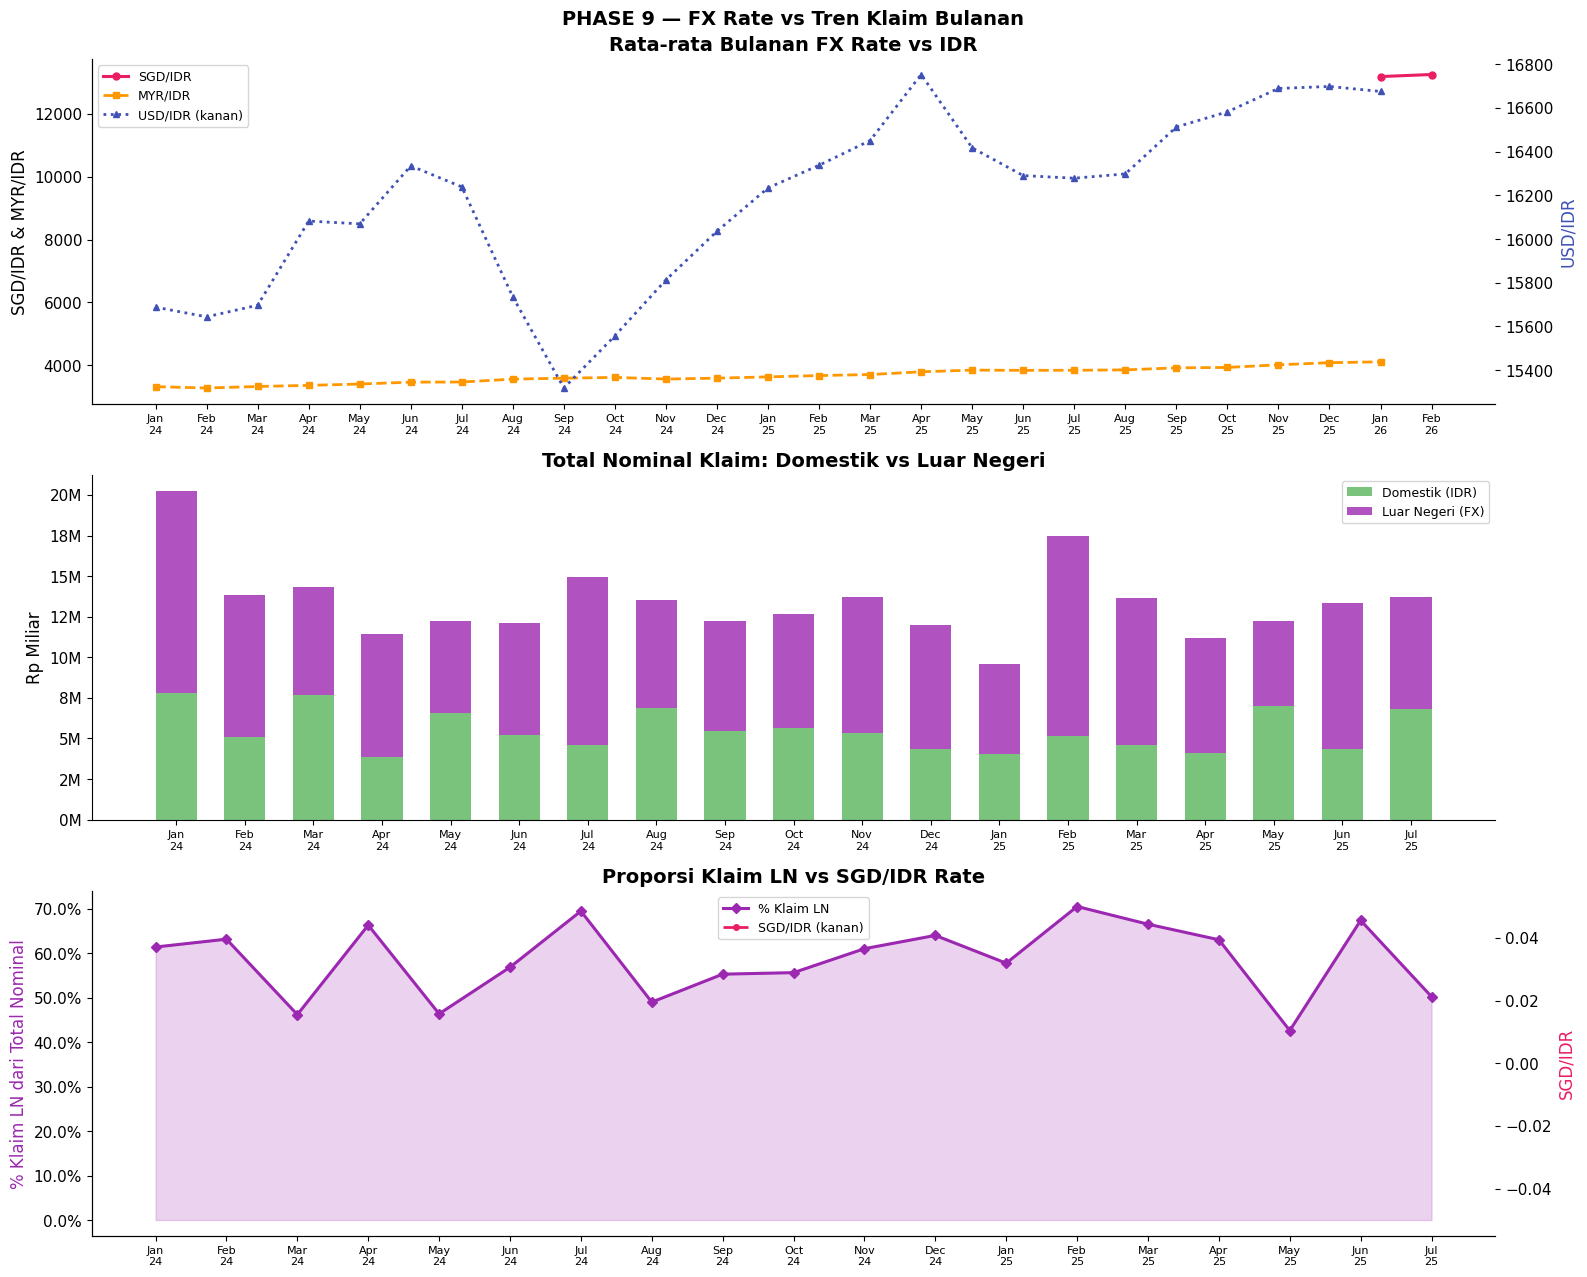

In [38]:
# ── Agregasi bulanan ────────────────────────────────────────────────
fx_all = pd.concat([fx_sgd, fx_myr, fx_usd])
fx_all['bulan'] = fx_all['date'].dt.to_period('M').dt.to_timestamp()
fx_monthly = fx_all.groupby(['bulan','currency'])['rate'].mean().reset_index()
fx_pivot = fx_monthly.pivot(index='bulan', columns='currency', values='rate').reset_index()

df['bulan_dt2'] = df['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()
klaim_by_cur = df.groupby(['bulan_dt2','currency_rs']).agg(
    n=('Claim ID','count'),
    total=('Nominal Klaim Yang Disetujui','sum')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('PHASE 9 — FX Rate vs Tren Klaim Bulanan', fontsize=14, fontweight='bold')

# FX tren
ax = axes[0]
ax_r = ax.twinx()
bulan_list = sorted(fx_pivot['bulan'].unique())
bulan_list = [b for b in bulan_list if b >= pd.Timestamp('2024-01-01')]
sub_fx = fx_pivot[fx_pivot['bulan'].isin(bulan_list)]
x = range(len(sub_fx))
xlabels = [b.strftime('%b\n%y') for b in sub_fx['bulan']]

if 'SGD' in sub_fx.columns:
    ax.plot(x, sub_fx['SGD'].values, color='#E91E63', lw=2.2, marker='o', ms=5, label='SGD/IDR')
if 'MYR' in sub_fx.columns:
    ax.plot(x, sub_fx['MYR'].values, color='#FF9800', lw=2, ls='--', marker='s', ms=4, label='MYR/IDR')
if 'USD' in sub_fx.columns:
    ax_r.plot(x, sub_fx['USD'].values, color='#3F51B5', lw=2, ls=':', marker='^', ms=4, label='USD/IDR (kanan)')
ax.set_ylabel('SGD/IDR & MYR/IDR'); ax_r.set_ylabel('USD/IDR', color='#3F51B5')
ax.set_title('Rata-rata Bulanan FX Rate vs IDR', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=8)
lines1,lab1 = ax.get_legend_handles_labels(); lines2,lab2 = ax_r.get_legend_handles_labels()
ax.legend(lines1+lines2, lab1+lab2, fontsize=9)

# Stacked bar LN vs domestik
ax2 = axes[1]
dom = klaim_by_cur[klaim_by_cur['currency_rs']=='IDR'].set_index('bulan_dt2')['total']
ln_cols = klaim_by_cur[klaim_by_cur['currency_rs']!='IDR'].groupby('bulan_dt2')['total'].sum()
all_bulan_k = sorted(set(dom.index.tolist() + ln_cols.index.tolist()))
all_bulan_k = [b for b in all_bulan_k if b >= pd.Timestamp('2024-01-01')]
xk = range(len(all_bulan_k))
xklabels = [b.strftime('%b\n%y') for b in all_bulan_k]

dom_vals = [dom.get(b, 0)/1e9 for b in all_bulan_k]
ln_vals  = [ln_cols.get(b, 0)/1e9 for b in all_bulan_k]
ax2.bar(xk, dom_vals, label='Domestik (IDR)', color='#4CAF50', alpha=0.75, width=0.6)
ax2.bar(xk, ln_vals, bottom=dom_vals, label='Luar Negeri (FX)', color='#9C27B0', alpha=0.8, width=0.6)
ax2.set_title('Total Nominal Klaim: Domestik vs Luar Negeri', fontweight='bold')
ax2.set_ylabel('Rp Miliar')
ax2.set_xticks(xk); ax2.set_xticklabels(xklabels, fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax2.legend(fontsize=9)

# % LN vs SGD rate
ax3 = axes[2]
ax3_r = ax3.twinx()
total_all = [dom_vals[i]+ln_vals[i] for i in range(len(all_bulan_k))]
pct_ln = [ln_vals[i]/total_all[i]*100 if total_all[i]>0 else 0 for i in range(len(all_bulan_k))]
ax3.fill_between(xk, pct_ln, alpha=0.2, color='#9C27B0')
ax3.plot(xk, pct_ln, color='#9C27B0', lw=2.2, marker='D', ms=5, label='% Klaim LN')
if 'SGD' in sub_fx.columns:
    # align SGD bulan ke xk
    sgd_vals_k = [sub_fx.set_index('bulan')['SGD'].get(b, np.nan) for b in all_bulan_k]
    ax3_r.plot(xk, sgd_vals_k, color='#E91E63', lw=2, ls='--', marker='o', ms=4, label='SGD/IDR (kanan)')
ax3.set_ylabel('% Klaim LN dari Total Nominal', color='#9C27B0')
ax3_r.set_ylabel('SGD/IDR', color='#E91E63')
ax3.set_title('Proporsi Klaim LN vs SGD/IDR Rate', fontweight='bold')
ax3.set_xticks(xk); ax3.set_xticklabels(xklabels, fontsize=8)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.1f}%'))
lines1,lab1 = ax3.get_legend_handles_labels(); lines2,lab2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1+lines2, lab1+lab2, fontsize=9)

plt.tight_layout()
import os; os.makedirs('charts', exist_ok=True)
plt.savefig('charts/fx_tren_klaim.png', dpi=120, bbox_inches='tight')
plt.show()


### 9.3 Beban per Lokasi RS: Total Nominal, Biaya dalam Mata Uang Asing & Selisih

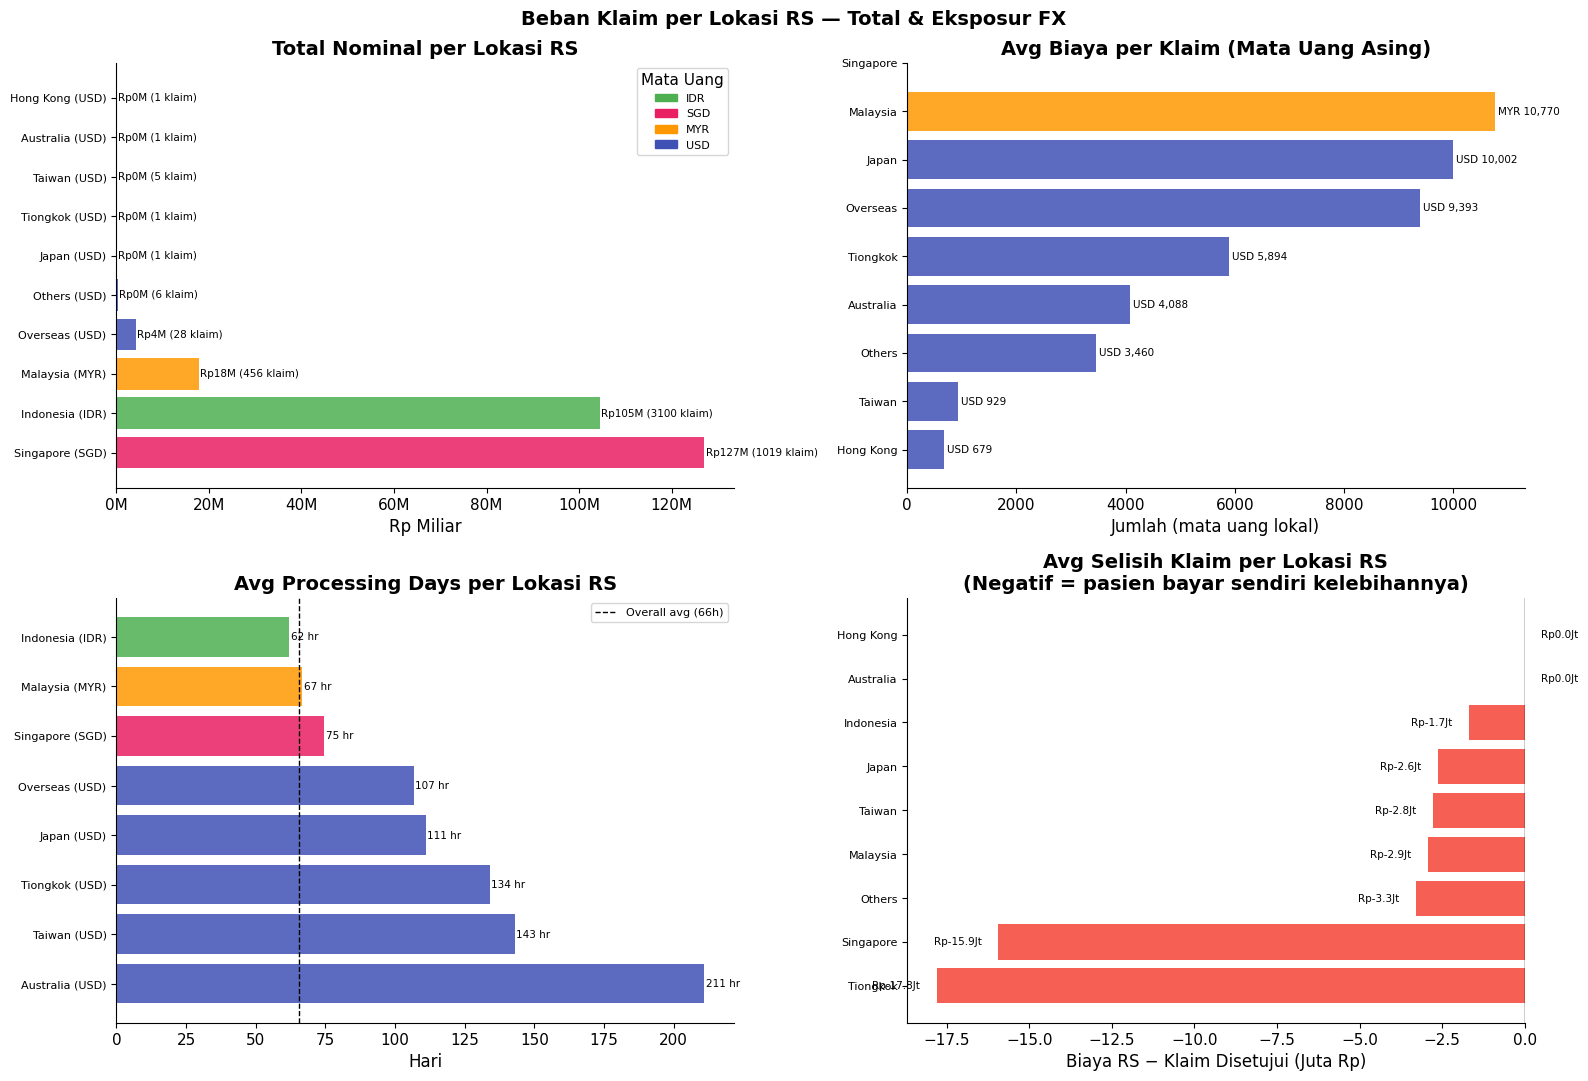


Summary per Lokasi:
Lokasi RS currency_rs    n  Avg IDR (Jt)  avg_foreign
Singapore         SGD 1019         124.7          NaN
Indonesia         IDR 3100          33.7          NaN
 Malaysia         MYR  456          39.1 10769.703885
 Overseas         USD   28         149.2  9393.089368
   Others         USD    6          57.4  3460.242890
    Japan         USD    1         162.2 10002.327043
 Tiongkok         USD    1          93.9  5894.176705
   Taiwan         USD    5          14.7   928.689388
Australia         USD    1          66.4  4087.706967
Hong Kong         USD    1          10.6   678.920579


In [39]:
lokasi_fx = df.groupby(['Lokasi RS','currency_rs']).agg(
    n=('Claim ID','count'),
    total_idr=('Nominal Klaim Yang Disetujui','sum'),
    avg_idr=('Nominal Klaim Yang Disetujui','mean'),
    avg_foreign=('nominal_foreign','mean'),
    avg_proc=('Processing_Days','mean'),
    avg_selisih=('Selisih_Klaim','mean'),
).reset_index().sort_values('total_idr', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Beban Klaim per Lokasi RS — Total & Eksposur FX', fontsize=14, fontweight='bold')

fx_colors = {'IDR':'#4CAF50','SGD':'#E91E63','MYR':'#FF9800','USD':'#3F51B5'}

# Total nominal
ax = axes[0,0]
top10 = lokasi_fx.head(10)
bar_cols = [fx_colors.get(c,'gray') for c in top10['currency_rs']]
bars = ax.barh(range(len(top10)), top10['total_idr']/1e9, color=bar_cols, alpha=0.85)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f"{r['Lokasi RS']} ({r['currency_rs']})" for _,r in top10.iterrows()], fontsize=8)
for bar,v,n in zip(bars, top10['total_idr'], top10['n']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'Rp{v/1e9:.0f}M ({n} klaim)', va='center', fontsize=7.5)
ax.set_title('Total Nominal per Lokasi RS', fontweight='bold')
ax.set_xlabel('Rp Miliar')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}M'))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v,label=k) for k,v in fx_colors.items()], fontsize=8, title='Mata Uang')

# Avg biaya dalam mata uang asing
ax = axes[0,1]
ln_data = lokasi_fx[lokasi_fx['currency_rs']!='IDR'].sort_values('avg_foreign', ascending=True)
bc = [fx_colors.get(c,'gray') for c in ln_data['currency_rs']]
b2 = ax.barh(range(len(ln_data)), ln_data['avg_foreign'], color=bc, alpha=0.85)
ax.set_yticks(range(len(ln_data)))
ax.set_yticklabels(ln_data['Lokasi RS'], fontsize=8)
for bar,row in zip(b2, ln_data.itertuples()):
    if pd.notna(row.avg_foreign):
        ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
                f'{row.currency_rs} {row.avg_foreign:,.0f}', va='center', fontsize=7.5)
ax.set_title('Avg Biaya per Klaim (Mata Uang Asing)', fontweight='bold')
ax.set_xlabel('Jumlah (mata uang lokal)')

# Processing days
ax = axes[1,0]
proc_data = lokasi_fx.sort_values('avg_proc', ascending=False).head(8)
bc3 = [fx_colors.get(c,'gray') for c in proc_data['currency_rs']]
b3 = ax.barh(range(len(proc_data)), proc_data['avg_proc'], color=bc3, alpha=0.85)
ax.set_yticks(range(len(proc_data)))
ax.set_yticklabels([f"{r['Lokasi RS']} ({r['currency_rs']})" for _,r in proc_data.iterrows()], fontsize=8)
for bar,v in zip(b3, proc_data['avg_proc']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{v:.0f} hr', va='center', fontsize=7.5)
avg_proc_all = df['Processing_Days'].mean()
ax.axvline(avg_proc_all, color='black', lw=1, ls='--', label=f'Overall avg ({avg_proc_all:.0f}h)')
ax.set_title('Avg Processing Days per Lokasi RS', fontweight='bold')
ax.set_xlabel('Hari'); ax.legend(fontsize=8)

# Selisih klaim (coverage gap)
ax = axes[1,1]
sel_data = lokasi_fx.sort_values('avg_selisih').head(9)
bc4 = ['#F44336' if v<0 else '#4CAF50' for v in sel_data['avg_selisih']]
b4 = ax.barh(range(len(sel_data)), sel_data['avg_selisih']/1e6, color=bc4, alpha=0.85)
ax.set_yticks(range(len(sel_data)))
ax.set_yticklabels(sel_data['Lokasi RS'], fontsize=8)
ax.axvline(0, color='black', lw=1)
for bar,v in zip(b4, sel_data['avg_selisih']):
    ax.text(bar.get_width()+(0.5 if v>=0 else -0.5), bar.get_y()+bar.get_height()/2,
            f'Rp{v/1e6:.1f}Jt', va='center', ha='left' if v>=0 else 'right', fontsize=7.5)
ax.set_title('Avg Selisih Klaim per Lokasi RS\n(Negatif = pasien bayar sendiri kelebihannya)', fontweight='bold')
ax.set_xlabel('Biaya RS − Klaim Disetujui (Juta Rp)')

plt.tight_layout()
plt.savefig('charts/fx_beban_lokasi.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSummary per Lokasi:')
print(lokasi_fx[['Lokasi RS','currency_rs','n','avg_idr','avg_foreign']].assign(
    avg_idr=lambda d: (d['avg_idr']/1e6).round(1)
).rename(columns={'avg_idr':'Avg IDR (Jt)'}).to_string(index=False))


### 9.4 Penyakit (ICD Group) × Lokasi RS × Cost Multiplier

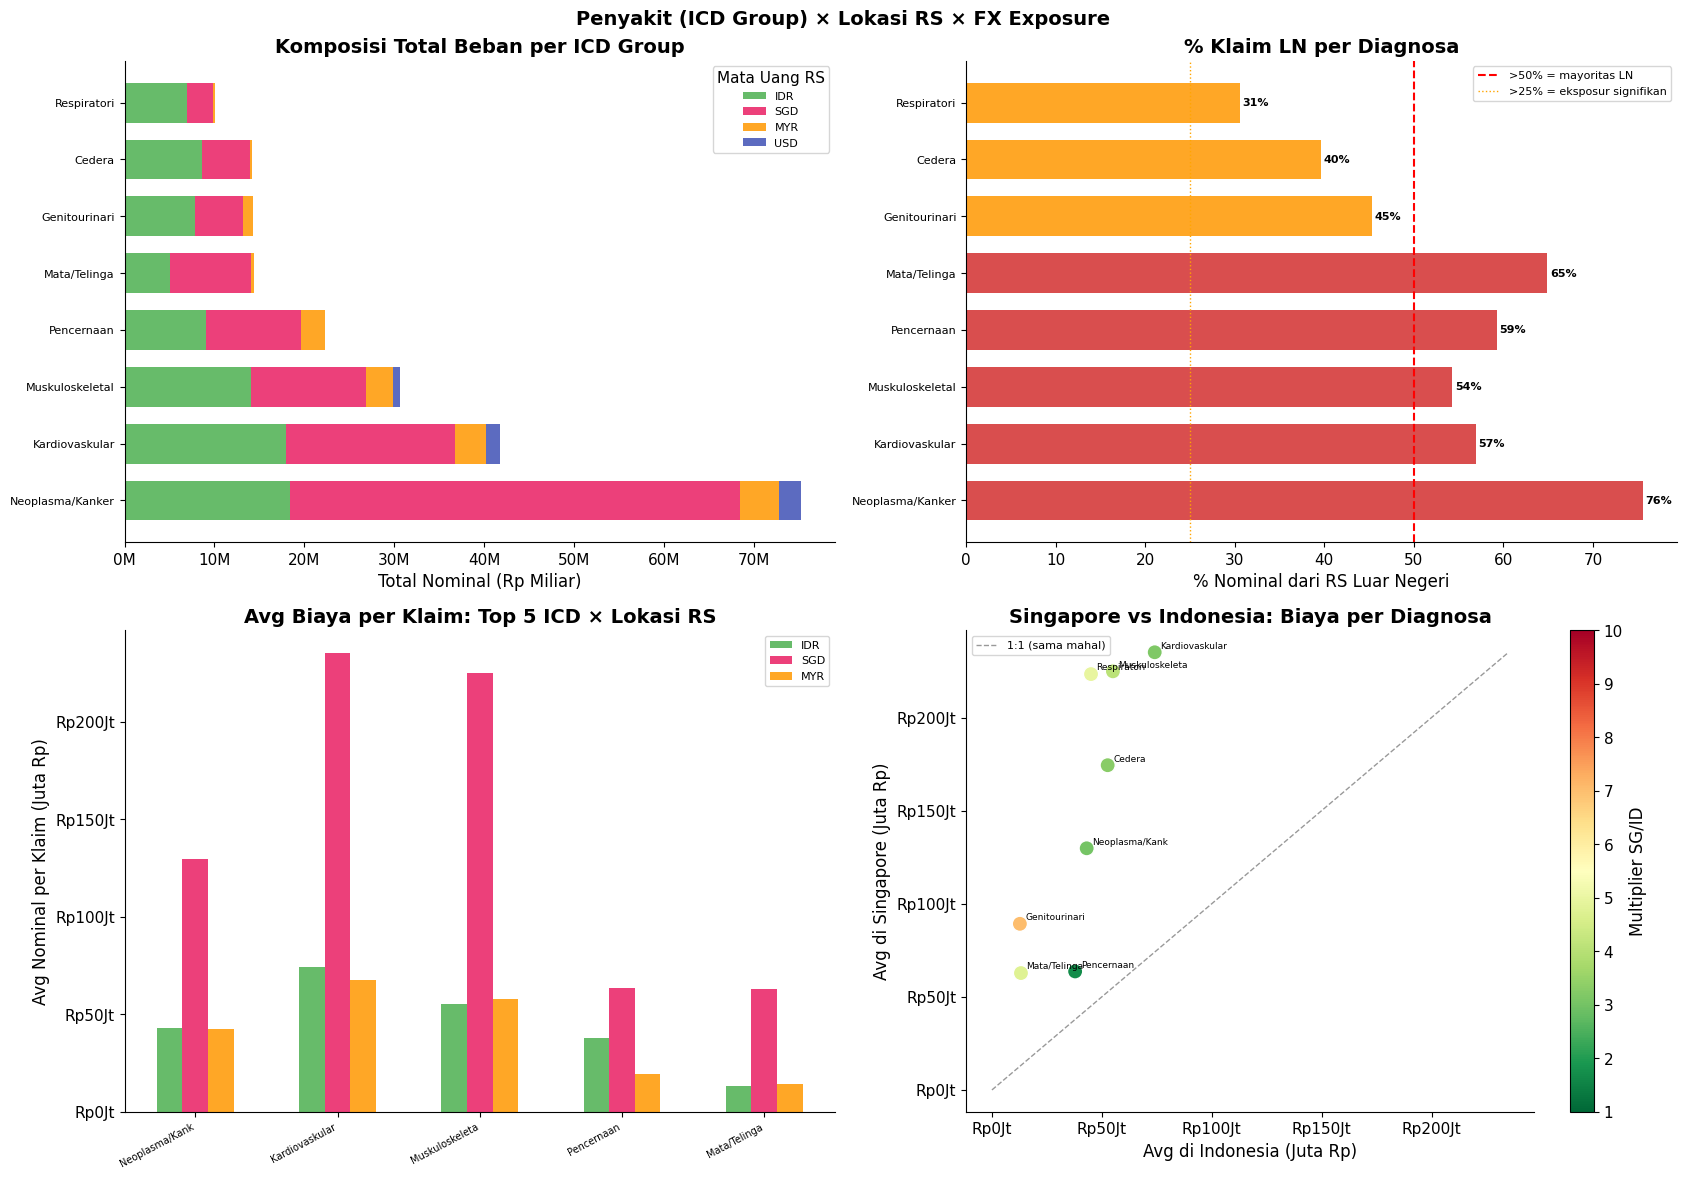

=== INSIGHT: ICD × FX EXPOSURE ===
  Neoplasma/Kanker                : 76% dari RS LN (Rp57M dari Rp75M)
  Mata/Telinga                    : 65% dari RS LN (Rp9M dari Rp14M)
  Pencernaan                      : 59% dari RS LN (Rp13M dari Rp22M)

  Paling mahal di SG: Genitourinari → 7.0x vs Indonesia


In [40]:
# Top 8 ICD Group by total nominal
top8_icd = df.groupby('ICD_Group')['Nominal Klaim Yang Disetujui'].sum().nlargest(8).index.tolist()

# Komposisi beban per ICD × currency
icd_cur = df.groupby(['ICD_Group','currency_rs'])['Nominal Klaim Yang Disetujui'].sum().reset_index()
icd_pivot = icd_cur.pivot_table(index='ICD_Group', columns='currency_rs',
                                  values='Nominal Klaim Yang Disetujui', fill_value=0)
icd_pivot['total'] = icd_pivot.sum(axis=1)
ln_c = [c for c in ['SGD','MYR','USD'] if c in icd_pivot.columns]
icd_pivot['total_ln'] = icd_pivot[ln_c].sum(axis=1) if ln_c else 0
icd_pivot['pct_ln'] = icd_pivot['total_ln'] / icd_pivot['total'] * 100
icd_pivot_top = icd_pivot.loc[[i for i in top8_icd if i in icd_pivot.index]]

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.suptitle('Penyakit (ICD Group) × Lokasi RS × FX Exposure', fontsize=14, fontweight='bold')

# Stacked bar komposisi
ax = axes[0,0]
y = range(len(icd_pivot_top))
left = np.zeros(len(icd_pivot_top))
for cur, color in [('IDR','#4CAF50'),('SGD','#E91E63'),('MYR','#FF9800'),('USD','#3F51B5')]:
    if cur in icd_pivot_top.columns:
        vals = icd_pivot_top[cur].values / 1e9
        ax.barh(y, vals, left=left, label=cur, color=color, alpha=0.85, height=0.7)
        left += vals
ax.set_yticks(y); ax.set_yticklabels(icd_pivot_top.index, fontsize=8)
ax.set_xlabel('Total Nominal (Rp Miliar)')
ax.set_title('Komposisi Total Beban per ICD Group', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax.legend(fontsize=8, title='Mata Uang RS')

# % LN per ICD
ax = axes[0,1]
pct_vals = icd_pivot_top['pct_ln'].values
bc_pct = ['#D32F2F' if v>50 else ('#FF9800' if v>25 else '#4CAF50') for v in pct_vals]
b2 = ax.barh(y, pct_vals, color=bc_pct, alpha=0.85, height=0.7)
ax.set_yticks(y); ax.set_yticklabels(icd_pivot_top.index, fontsize=8)
ax.axvline(50, color='red', lw=1.5, ls='--', label='>50% = mayoritas LN')
ax.axvline(25, color='orange', lw=1, ls=':', label='>25% = eksposur signifikan')
for bar,v in zip(b2, pct_vals):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v:.0f}%', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('% Nominal dari RS Luar Negeri')
ax.set_title('% Klaim LN per Diagnosa', fontweight='bold')
ax.legend(fontsize=8)

# Avg biaya IDR: top 5 ICD × lokasi (clustered bar)
ax = axes[1,0]
top5_icd = top8_icd[:5]
icd_avg_loc = df[df['ICD_Group'].isin(top5_icd)].groupby(['ICD_Group','currency_rs'])['Nominal Klaim Yang Disetujui'].mean().reset_index()
icd_avg_pivot = icd_avg_loc.pivot(index='ICD_Group', columns='currency_rs', values='Nominal Klaim Yang Disetujui').reindex(top5_icd)
bw = 0.18
xidx = np.arange(len(top5_icd))
off = 0
for cur, color in [('IDR','#4CAF50'),('SGD','#E91E63'),('MYR','#FF9800')]:
    if cur in icd_avg_pivot.columns:
        ax.bar(xidx+off, icd_avg_pivot[cur].fillna(0)/1e6, width=bw, label=cur, color=color, alpha=0.85)
        off += bw
ax.set_xticks(xidx+bw); ax.set_xticklabels([g[:14] for g in top5_icd], rotation=28, ha='right', fontsize=7)
ax.set_ylabel('Avg Nominal per Klaim (Juta Rp)')
ax.set_title('Avg Biaya per Klaim: Top 5 ICD × Lokasi RS', fontweight='bold')
ax.legend(fontsize=8); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'Rp{v:.0f}Jt'))

# Scatter: avg IDR vs avg SGD per ICD
ax = axes[1,1]
scatter_pts = []
for icd in top8_icd:
    idr_avg = df[(df['ICD_Group']==icd)&(df['currency_rs']=='IDR')]['Nominal Klaim Yang Disetujui'].mean()
    sgd_avg = df[(df['ICD_Group']==icd)&(df['currency_rs']=='SGD')]['Nominal Klaim Yang Disetujui'].mean()
    if pd.notna(idr_avg) and pd.notna(sgd_avg):
        scatter_pts.append({'ICD':icd,'IDR':idr_avg,'SGD':sgd_avg,'ratio':sgd_avg/idr_avg})

if scatter_pts:
    sdf = pd.DataFrame(scatter_pts)
    sc = ax.scatter(sdf['IDR']/1e6, sdf['SGD']/1e6, c=sdf['ratio'],
                    cmap='RdYlGn_r', s=120, edgecolors='white', linewidths=1, vmin=1, vmax=10)
    for _,row in sdf.iterrows():
        ax.annotate(row['ICD'][:14], (row['IDR']/1e6, row['SGD']/1e6), fontsize=6.5, xytext=(4,3), textcoords='offset points')
    mv = max(sdf[['IDR','SGD']].max().max()/1e6, 1)
    ax.plot([0,mv],[0,mv],'k--',lw=1,alpha=0.4,label='1:1 (sama mahal)')
    plt.colorbar(sc, ax=ax, label='Multiplier SG/ID')
ax.set_xlabel('Avg di Indonesia (Juta Rp)'); ax.set_ylabel('Avg di Singapore (Juta Rp)')
ax.set_title('Singapore vs Indonesia: Biaya per Diagnosa', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'Rp{v:.0f}Jt'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'Rp{v:.0f}Jt'))
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('charts/fx_icd_lokasi.png', dpi=120, bbox_inches='tight')
plt.show()

# Insight
print('=== INSIGHT: ICD × FX EXPOSURE ===')
top3_pct = icd_pivot_top.nlargest(3,'pct_ln')
for icd,row in top3_pct.iterrows():
    print(f'  {icd:<32}: {row["pct_ln"]:.0f}% dari RS LN (Rp{row["total_ln"]/1e9:.0f}M dari Rp{row["total"]/1e9:.0f}M)')
if scatter_pts:
    top1 = sdf.sort_values('ratio',ascending=False).iloc[0]
    print(f'\n  Paling mahal di SG: {top1["ICD"]} → {top1["ratio"]:.1f}x vs Indonesia')


### 9.5 Counterfactual: Berapa Ekstra Bayar Akibat Depresiasi IDR?

Baseline FX (rata-rata Jan 2024):
  SGD/IDR: nan  |  MYR/IDR: 3,323  |  USD/IDR: 15,688

Total nominal klaim aktual        : Rp254.58 Miliar
Jika FX tetap di Jan-2024         : Rp252.99 Miliar
Dampak perubahan FX               : Rp+1.59 Miliar (+0.6%)


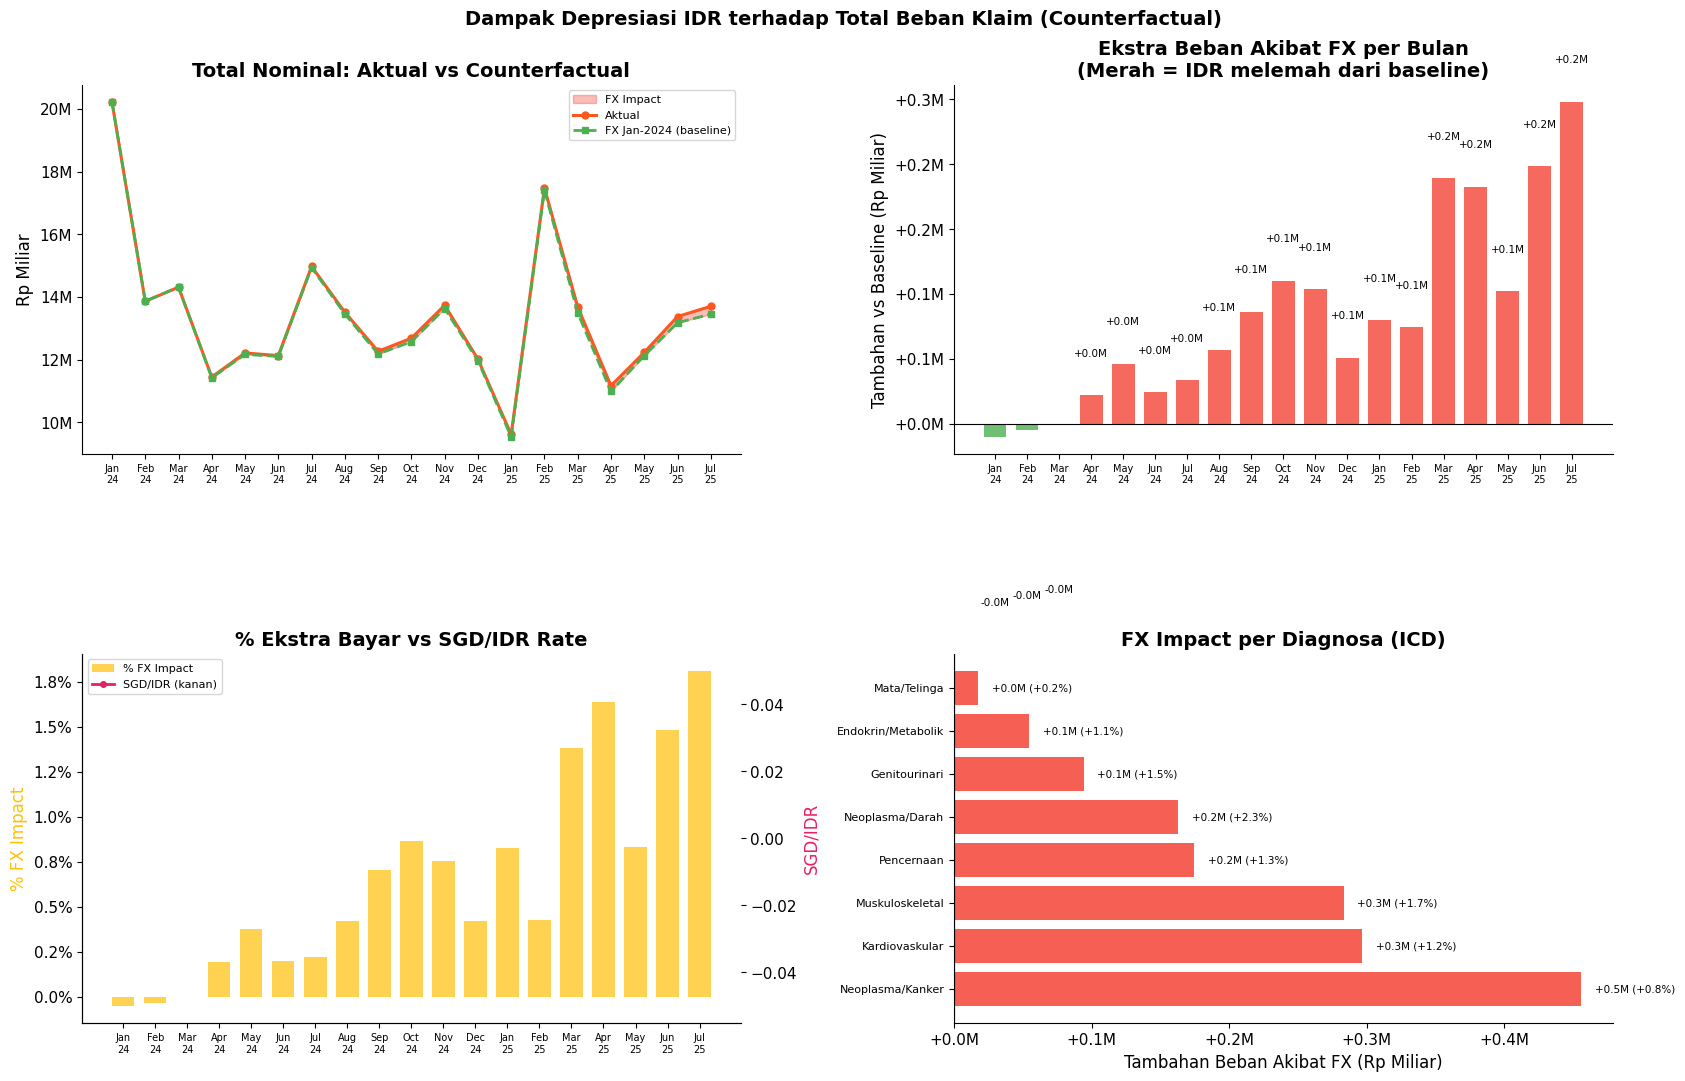


=== RINGKASAN FX IMPACT ===
Total FX impact: Rp+1.59M (+0.6% dari total beban)

Top 3 diagnosa paling terekspos FX:
  Neoplasma/Kanker              : Rp+0.5M (+0.8%)
  Kardiovaskular                : Rp+0.3M (+1.2%)
  Muskuloskeletal               : Rp+0.3M (+1.7%)


In [41]:
# Baseline FX = rata-rata Januari 2024
def baseline_rate(fx_df):
    mask = (fx_df['date'] >= '2024-01-01') & (fx_df['date'] <= '2024-01-31')
    return fx_df.loc[mask,'rate'].mean()

base_sgd = baseline_rate(fx_sgd)
base_myr = baseline_rate(fx_myr)
base_usd = baseline_rate(fx_usd)

print(f'Baseline FX (rata-rata Jan 2024):')
print(f'  SGD/IDR: {base_sgd:,.0f}  |  MYR/IDR: {base_myr:,.0f}  |  USD/IDR: {base_usd:,.0f}')

def nominal_baseline(row):
    if row['currency_rs']=='IDR' or pd.isna(row['fx_rate_masuk']) or row['fx_rate_masuk']==0:
        return row['Nominal Klaim Yang Disetujui']
    foreign = row['Nominal Klaim Yang Disetujui'] / row['fx_rate_masuk']
    if row['currency_rs']=='SGD': return foreign * base_sgd
    elif row['currency_rs']=='MYR': return foreign * base_myr
    elif row['currency_rs']=='USD': return foreign * base_usd
    return row['Nominal Klaim Yang Disetujui']

df['nominal_baseline_fx'] = df.apply(nominal_baseline, axis=1)
df['fx_impact_idr'] = df['Nominal Klaim Yang Disetujui'] - df['nominal_baseline_fx']

total_act = df['Nominal Klaim Yang Disetujui'].sum()
total_base = df['nominal_baseline_fx'].sum()
total_impact = df['fx_impact_idr'].sum()

print(f'\nTotal nominal klaim aktual        : Rp{total_act/1e9:.2f} Miliar')
print(f'Jika FX tetap di Jan-2024         : Rp{total_base/1e9:.2f} Miliar')
print(f'Dampak perubahan FX               : Rp{total_impact/1e9:+.2f} Miliar ({total_impact/total_act*100:+.1f}%)')

# Bulanan
cf_monthly = df.groupby('bulan_dt2').agg(
    actual=('Nominal Klaim Yang Disetujui','sum'),
    baseline=('nominal_baseline_fx','sum'),
    fx_impact=('fx_impact_idr','sum'),
).reset_index().sort_values('bulan_dt2')
cf_monthly = cf_monthly[cf_monthly['bulan_dt2']>='2024-01-01']
cf_monthly['pct_impact'] = cf_monthly['fx_impact'] / cf_monthly['actual'] * 100

# ICD counterfactual
cf_icd = df[df['currency_rs']!='IDR'].groupby('ICD_Group').agg(
    actual=('Nominal Klaim Yang Disetujui','sum'),
    baseline=('nominal_baseline_fx','sum'),
    fx_impact=('fx_impact_idr','sum'),
    n=('Claim ID','count'),
).reset_index()
cf_icd['pct_impact'] = cf_icd['fx_impact']/cf_icd['actual']*100
cf_icd = cf_icd.sort_values('fx_impact',ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle('Dampak Depresiasi IDR terhadap Total Beban Klaim (Counterfactual)', fontsize=14, fontweight='bold')

x = range(len(cf_monthly))
xbl = [b.strftime('%b\n%y') for b in cf_monthly['bulan_dt2']]

# Aktual vs baseline
ax = axes[0,0]
ax.fill_between(x, cf_monthly['baseline']/1e9, cf_monthly['actual']/1e9, alpha=0.35, color='#F44336', label='FX Impact')
ax.plot(x, cf_monthly['actual']/1e9, color='#FF5722', lw=2.2, marker='o', ms=5, label='Aktual')
ax.plot(x, cf_monthly['baseline']/1e9, color='#4CAF50', lw=2, ls='--', marker='s', ms=4, label='FX Jan-2024 (baseline)')
ax.set_title('Total Nominal: Aktual vs Counterfactual', fontweight='bold')
ax.set_ylabel('Rp Miliar'); ax.set_xticks(x); ax.set_xticklabels(xbl, fontsize=7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax.legend(fontsize=8)

# FX Impact per bulan
ax = axes[0,1]
bc2 = ['#F44336' if v>0 else '#4CAF50' for v in cf_monthly['fx_impact']]
b2 = ax.bar(x, cf_monthly['fx_impact']/1e9, color=bc2, alpha=0.8, width=0.7)
ax.axhline(0, color='black', lw=0.8)
for bar,v in zip(b2, cf_monthly['fx_impact']):
    if abs(v)>0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.03 if v>=0 else -0.13),
                f'{v/1e9:+.1f}M', ha='center', fontsize=7.5)
ax.set_title('Ekstra Beban Akibat FX per Bulan\n(Merah = IDR melemah dari baseline)', fontweight='bold')
ax.set_ylabel('Tambahan vs Baseline (Rp Miliar)')
ax.set_xticks(x); ax.set_xticklabels(xbl, fontsize=7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:+.1f}M'))

# % impact
ax = axes[1,0]
ax_r = ax.twinx()
ax.bar(x, cf_monthly['pct_impact'], color='#FFC107', alpha=0.7, width=0.7, label='% FX Impact')
sub_sgd = [(fx_pivot[fx_pivot['bulan']==b]['SGD'].values[0] if b in fx_pivot['bulan'].values and 'SGD' in fx_pivot.columns else np.nan)
           for b in cf_monthly['bulan_dt2']]
ax_r.plot(x, sub_sgd, color='#E91E63', lw=2, marker='o', ms=4, label='SGD/IDR (kanan)')
ax.set_ylabel('% FX Impact', color='#FFC107')
ax_r.set_ylabel('SGD/IDR', color='#E91E63')
ax.set_title('% Ekstra Bayar vs SGD/IDR Rate', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(xbl, fontsize=7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.1f}%'))
l1,lb1 = ax.get_legend_handles_labels(); l2,lb2 = ax_r.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=8)

# FX impact per ICD
ax = axes[1,1]
top8_cf = cf_icd.head(8)
bc3 = ['#F44336' if v>0 else '#4CAF50' for v in top8_cf['fx_impact']]
b3 = ax.barh(range(len(top8_cf)), top8_cf['fx_impact']/1e9, color=bc3, alpha=0.85)
ax.set_yticks(range(len(top8_cf))); ax.set_yticklabels(top8_cf['ICD_Group'], fontsize=8)
for bar,v,pct in zip(b3, top8_cf['fx_impact'], top8_cf['pct_impact']):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{v/1e9:+.1f}M ({pct:+.1f}%)', va='center', fontsize=7.5)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Tambahan Beban Akibat FX (Rp Miliar)')
ax.set_title('FX Impact per Diagnosa (ICD)', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:+.1f}M'))

plt.tight_layout()
plt.savefig('charts/fx_counterfactual.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n=== RINGKASAN FX IMPACT ===')
print(f'Total FX impact: Rp{total_impact/1e9:+.2f}M ({total_impact/total_act*100:+.1f}% dari total beban)')
print(f'\nTop 3 diagnosa paling terekspos FX:')
for _,row in cf_icd.head(3).iterrows():
    print(f'  {row["ICD_Group"]:<30}: Rp{row["fx_impact"]/1e9:+.1f}M ({row["pct_impact"]:+.1f}%)')


---
### 9.6 FX Rate × Total Nominal Klaim per Lokasi — Satu Plot per Mata Uang
*(Dual-axis line: kurs di kiri, total nominal klaim di kanan — tren bulanan)*

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Rebuild FX monthly lookup (bersih, no reindex issue) ─────────────
def load_fx_clean(path, cur):
    df_fx = pd.read_csv(path)
    df_fx.columns = df_fx.columns.str.strip()
    def parse(s):
        s = str(s).strip().replace('.','').replace(',','.')
        try: return float(s)
        except: return np.nan
    df_fx['date'] = pd.to_datetime(df_fx['Tanggal'], format='%d/%m/%Y', dayfirst=True)
    df_fx['rate'] = df_fx['Terakhir'].apply(parse)
    df_fx = df_fx.dropna(subset=['rate']).sort_values('date')
    df_fx['bulan'] = df_fx['date'].dt.to_period('M').dt.to_timestamp()
    monthly = df_fx.groupby('bulan')['rate'].mean().reset_index()
    monthly.columns = ['bulan', cur]
    monthly['bulan'] = pd.to_datetime(monthly['bulan'])   # normalize dtype
    return monthly

sgd_m = load_fx_clean('dataset/Data Historis SGD_IDR.csv', 'SGD')
myr_m = load_fx_clean('dataset/Data Historis MYR_IDR.csv', 'MYR')
usd_m = load_fx_clean('dataset/Data Historis USD_IDR.csv', 'USD')

# ── Nominal klaim bulanan per lokasi ─────────────────────────────────
df_raw = pd.read_csv('dataset/Data_Klaim_Enriched.csv',
                     parse_dates=['Tanggal Pasien Masuk RS'])
df_raw['bulan'] = pd.to_datetime(
    df_raw['Tanggal Pasien Masuk RS'].dt.to_period('M').dt.to_timestamp()
)

def klaim_bulanan_lokasi(lokasi_list, label):
    sub = df_raw[df_raw['Lokasi RS'].isin(lokasi_list)].groupby('bulan').agg(
        total_nom = ('Nominal Klaim Yang Disetujui','sum'),
        n_klaim   = ('Claim ID','count'),
        avg_nom   = ('Nominal Klaim Yang Disetujui','mean'),
    ).reset_index()
    sub['lokasi_label'] = label
    return sub

klaim_sg  = klaim_bulanan_lokasi(['Singapore'], 'Singapore')
klaim_my  = klaim_bulanan_lokasi(['Malaysia'],  'Malaysia')
klaim_usd = klaim_bulanan_lokasi(['Taiwan','Hong Kong','Japan','Tiongkok','Australia','Overseas','Others'], 'Others (USD)')

# ── Merge FX + klaim per pasangan mata uang ───────────────────────────
def merge_fx_klaim(klaim_df, fx_df, fx_col):
    k = klaim_df.copy()
    f = fx_df.copy()
    # Normalize both to plain Timestamp to avoid dtype mismatch
    k['bulan'] = pd.to_datetime(k['bulan'])
    f['bulan'] = pd.to_datetime(f['bulan'])
    merged = k.merge(f, on='bulan', how='inner')
    merged = merged[merged['bulan'] >= '2024-01-01'].sort_values('bulan')
    return merged

sg_data  = merge_fx_klaim(klaim_sg,  sgd_m, 'SGD')
my_data  = merge_fx_klaim(klaim_my,  myr_m, 'MYR')
usd_data = merge_fx_klaim(klaim_usd, usd_m, 'USD')

print("klaim_sg rows:", len(klaim_sg), "| bulan dtype:", klaim_sg['bulan'].dtype if len(klaim_sg) else 'N/A')
print("sgd_m rows:",   len(sgd_m),    "| bulan dtype:", sgd_m['bulan'].dtype)
print()
print("Data SGD–Singapore:", sg_data.shape)
print(sg_data[['bulan','SGD','total_nom','n_klaim']].round(0).to_string(index=False))

klaim_sg rows: 19 | bulan dtype: datetime64[us]
sgd_m rows: 2 | bulan dtype: datetime64[us]

Data SGD–Singapore: (0, 6)
Empty DataFrame
Columns: [bulan, SGD, total_nom, n_klaim]
Index: []


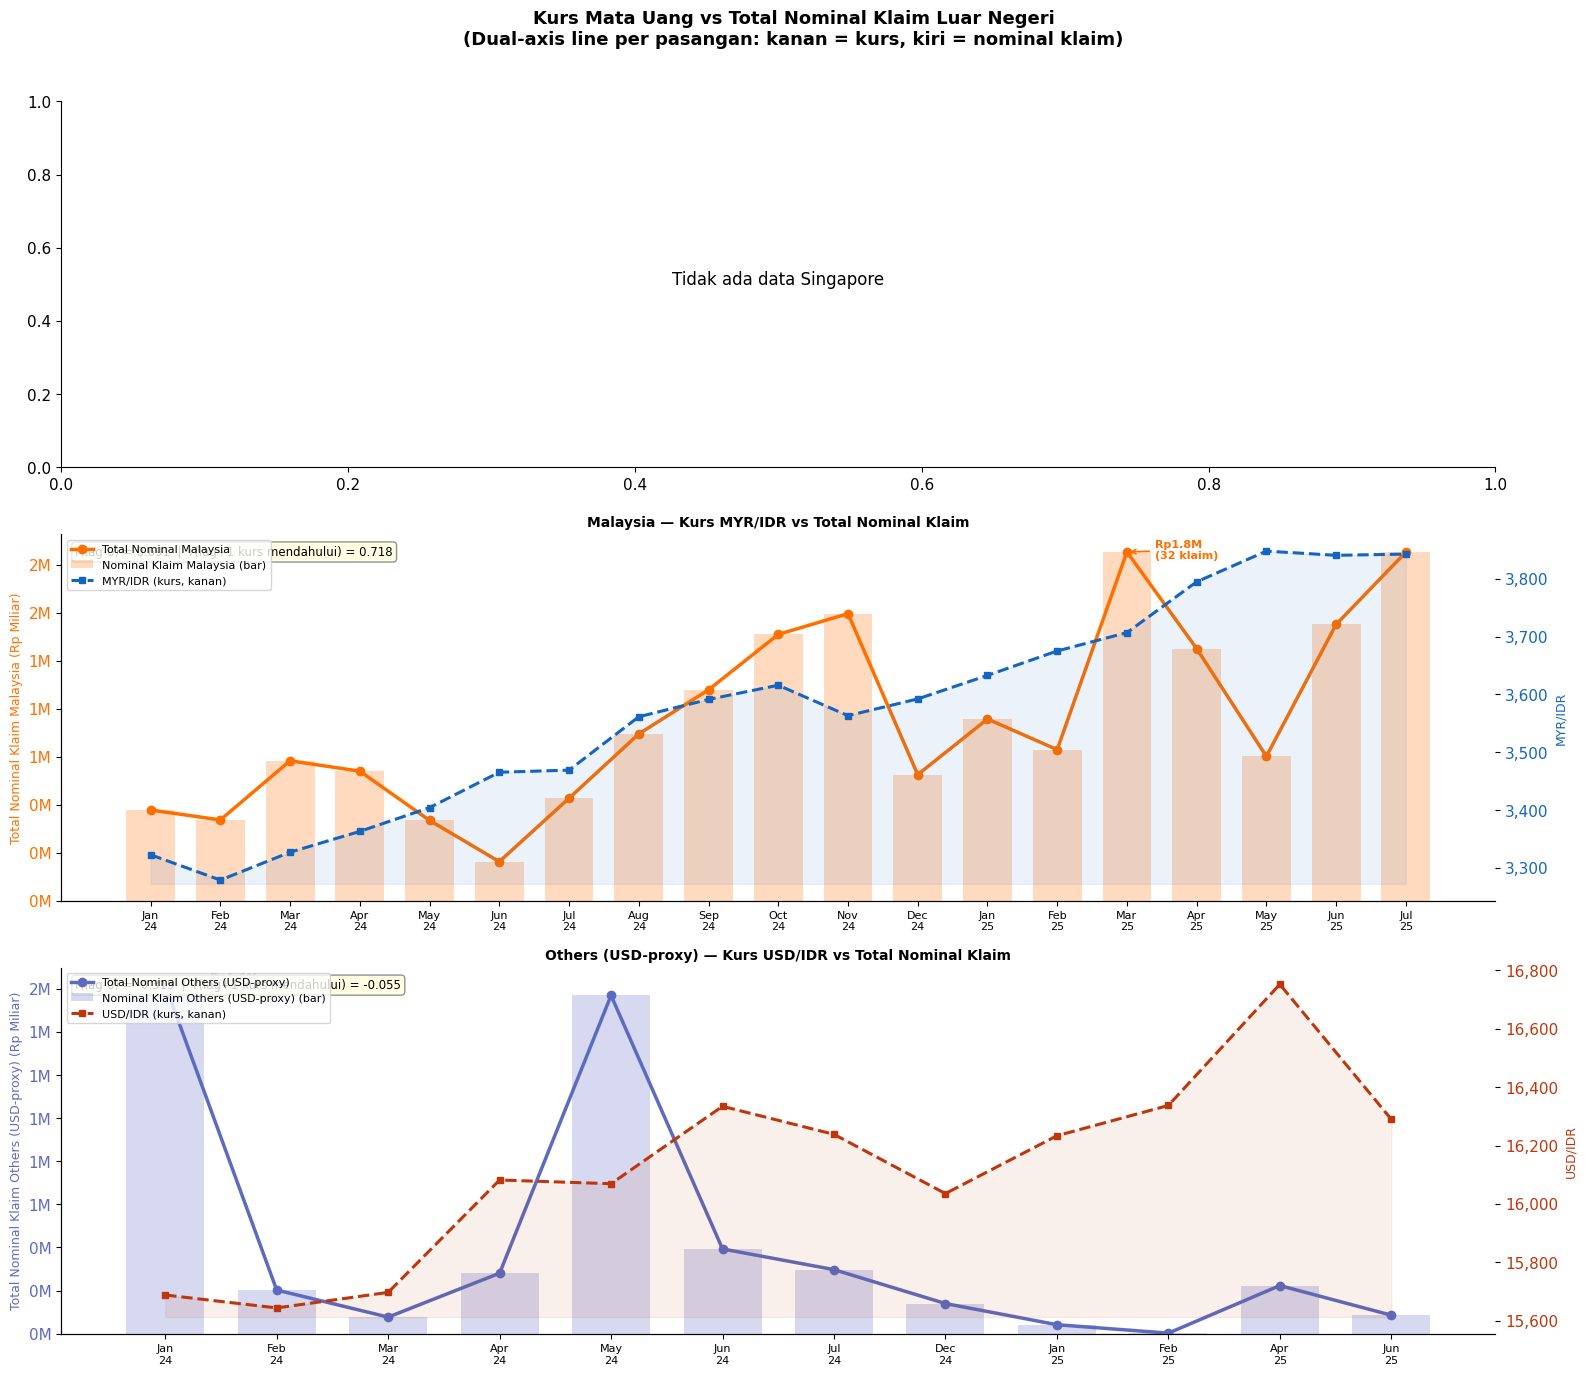

In [43]:

# ── Plot 3 pasangan: SGD/SG, MYR/MY, USD/Others ─────────────────────
CONFIGS = [
    (sg_data,  'SGD', 'Singapore',       '#E91E63', '#4CAF50',  'SGD/IDR',  'Singapore'),
    (my_data,  'MYR', 'Malaysia',        '#FF6F00', '#1565C0',  'MYR/IDR',  'Malaysia'),
    (usd_data, 'USD', 'Others (USD-proxy)', '#5C6BC0', '#BF360C', 'USD/IDR', 'Others LN'),
]

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)
fig.suptitle('Kurs Mata Uang vs Total Nominal Klaim Luar Negeri\n'
             '(Dual-axis line per pasangan: kanan = kurs, kiri = nominal klaim)',
             fontsize=13, fontweight='bold')

for ax, (data, fx_col, lokasi, c_nom, c_fx, ylabel_fx, ylabel_nom) in zip(axes, CONFIGS):
    if data.empty:
        ax.text(0.5, 0.5, f'Tidak ada data {lokasi}', ha='center', transform=ax.transAxes, fontsize=12)
        continue

    x = range(len(data))
    xlabels = [b.strftime('%b\n%y') for b in data['bulan']]

    ax_r = ax.twinx()

    # Kiri: total nominal klaim (bar + line)
    ax.bar(x, data['total_nom']/1e9, color=c_nom, alpha=0.25, width=0.7, label=f'Nominal Klaim {lokasi} (bar)')
    ax.plot(x, data['total_nom']/1e9, color=c_nom, lw=2.5, marker='o', ms=6,
            label=f'Total Nominal {lokasi}', zorder=3)

    # Kanan: kurs
    ax_r.plot(x, data[fx_col], color=c_fx, lw=2.2, marker='s', ms=5, ls='--',
              label=f'{ylabel_fx} (kurs, kanan)', zorder=3)
    ax_r.fill_between(x, data[fx_col], data[fx_col].min()*0.998,
                      alpha=0.08, color=c_fx)

    # Annotate: titik tertinggi nominal
    idx_max = data['total_nom'].idxmax()
    pos_max = list(data.index).index(idx_max)
    ax.annotate(
        f"Rp{data.loc[idx_max,'total_nom']/1e9:.1f}M\n({data.loc[idx_max,'n_klaim']} klaim)",
        xy=(pos_max, data.loc[idx_max,'total_nom']/1e9),
        xytext=(pos_max+0.4, data.loc[idx_max,'total_nom']/1e9 * 0.98),
        fontsize=8, color=c_nom, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=c_nom, lw=1.2)
    )

    # Korelasi
    corr = data['total_nom'].corr(data[fx_col])
    corr_lag1 = data['total_nom'].corr(data[fx_col].shift(1))
    ax.text(0.01, 0.97,
            f'r(lag-0) = {corr:.3f}  |  r(lag+1 kurs mendahului) = {corr_lag1:.3f}',
            transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.85))

    ax.set_ylabel(f'Total Nominal Klaim {lokasi} (Rp Miliar)', color=c_nom, fontsize=9)
    ax_r.set_ylabel(f'{ylabel_fx}', color=c_fx, fontsize=9)
    ax.tick_params(axis='y', labelcolor=c_nom)
    ax_r.tick_params(axis='y', labelcolor=c_fx)
    ax.set_title(f'{lokasi} — Kurs {ylabel_fx} vs Total Nominal Klaim', fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
    ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.97])
import os; os.makedirs('charts', exist_ok=True)
plt.savefig('charts/fx_vs_klaim_perlokasi.png', dpi=120, bbox_inches='tight')
plt.show()


In [44]:

# ── Insight korelasi FX vs nominal per lokasi ─────────────────────────
print('=== KORELASI KURS vs NOMINAL KLAIM ===\n')

for data, fx_col, lokasi in [
    (sg_data,  'SGD', 'Singapore'),
    (my_data,  'MYR', 'Malaysia'),
    (usd_data, 'USD', 'Others LN'),
]:
    if data.empty or len(data) < 4:
        print(f'{lokasi}: data tidak cukup ({len(data)} bulan)\n')
        continue

    r0   = data['total_nom'].corr(data[fx_col])
    r_l1 = data['total_nom'].corr(data[fx_col].shift(1))   # kurs t-1 → klaim t
    r_l2 = data['total_nom'].corr(data[fx_col].shift(2))   # kurs t-2 → klaim t
    r_f1 = data['total_nom'].corr(data[fx_col].shift(-1))  # kurs t → klaim t+1

    print(f'[{lokasi}] ({fx_col}/IDR vs Total Nominal Klaim)')
    print(f'  r(kurs t  vs klaim t)   = {r0:+.3f}  ← korelasi bulan yang sama')
    print(f'  r(kurs t-1 vs klaim t) = {r_l1:+.3f}  ← apakah kurs bulan lalu prediktif?')
    print(f'  r(kurs t-2 vs klaim t) = {r_l2:+.3f}')
    print(f'  r(kurs t  vs klaim t+1)= {r_f1:+.3f}  ← apakah kurs sekarang prediksi klaim bulan depan?')

    # Interpretasi
    best_r, best_lag = max(
        [(abs(r0),'lag-0'), (abs(r_l1),'kurs t-1'), (abs(r_l2),'kurs t-2'), (abs(r_f1),'kurs t→klaim t+1')]
    )
    direction = 'positif (+)' if (r0>=0) else 'negatif (-)'
    if best_r >= 0.5:
        print(f'  → KORELASI {direction} KUAT (best: {best_lag}, r={best_r:.3f})')
        print(f'     IDR melemah (kurs naik) berkaitan dengan {"kenaikan" if r0>0 else "penurunan"} nominal klaim LN')
    elif best_r >= 0.3:
        print(f'  → Korelasi moderat (best: {best_lag}, r={best_r:.3f})')
    else:
        print(f'  → Korelasi lemah — volume klaim tidak dipengaruhi langsung oleh kurs')
        print(f'     (klaim LN lebih dipengaruhi faktor medis/musiman daripada pergerakan kurs)')
    print()


=== KORELASI KURS vs NOMINAL KLAIM ===

Singapore: data tidak cukup (0 bulan)

[Malaysia] (MYR/IDR vs Total Nominal Klaim)
  r(kurs t  vs klaim t)   = +0.691  ← korelasi bulan yang sama
  r(kurs t-1 vs klaim t) = +0.718  ← apakah kurs bulan lalu prediktif?
  r(kurs t-2 vs klaim t) = +0.713
  r(kurs t  vs klaim t+1)= +0.637  ← apakah kurs sekarang prediksi klaim bulan depan?
  → KORELASI positif (+) KUAT (best: kurs t-1, r=0.718)
     IDR melemah (kurs naik) berkaitan dengan kenaikan nominal klaim LN

[Others LN] (USD/IDR vs Total Nominal Klaim)
  r(kurs t  vs klaim t)   = -0.315  ← korelasi bulan yang sama
  r(kurs t-1 vs klaim t) = -0.055  ← apakah kurs bulan lalu prediktif?
  r(kurs t-2 vs klaim t) = -0.467
  r(kurs t  vs klaim t+1)= -0.348  ← apakah kurs sekarang prediksi klaim bulan depan?
  → Korelasi moderat (best: kurs t-2, r=0.467)



---
### 9.7 Kurs FX vs Total Biaya & Jumlah Pasien per Penyakit per Negara
*(1 plot per kombinasi negara × penyakit — pasien (bar), total biaya (garis kiri), kurs (garis kanan))*

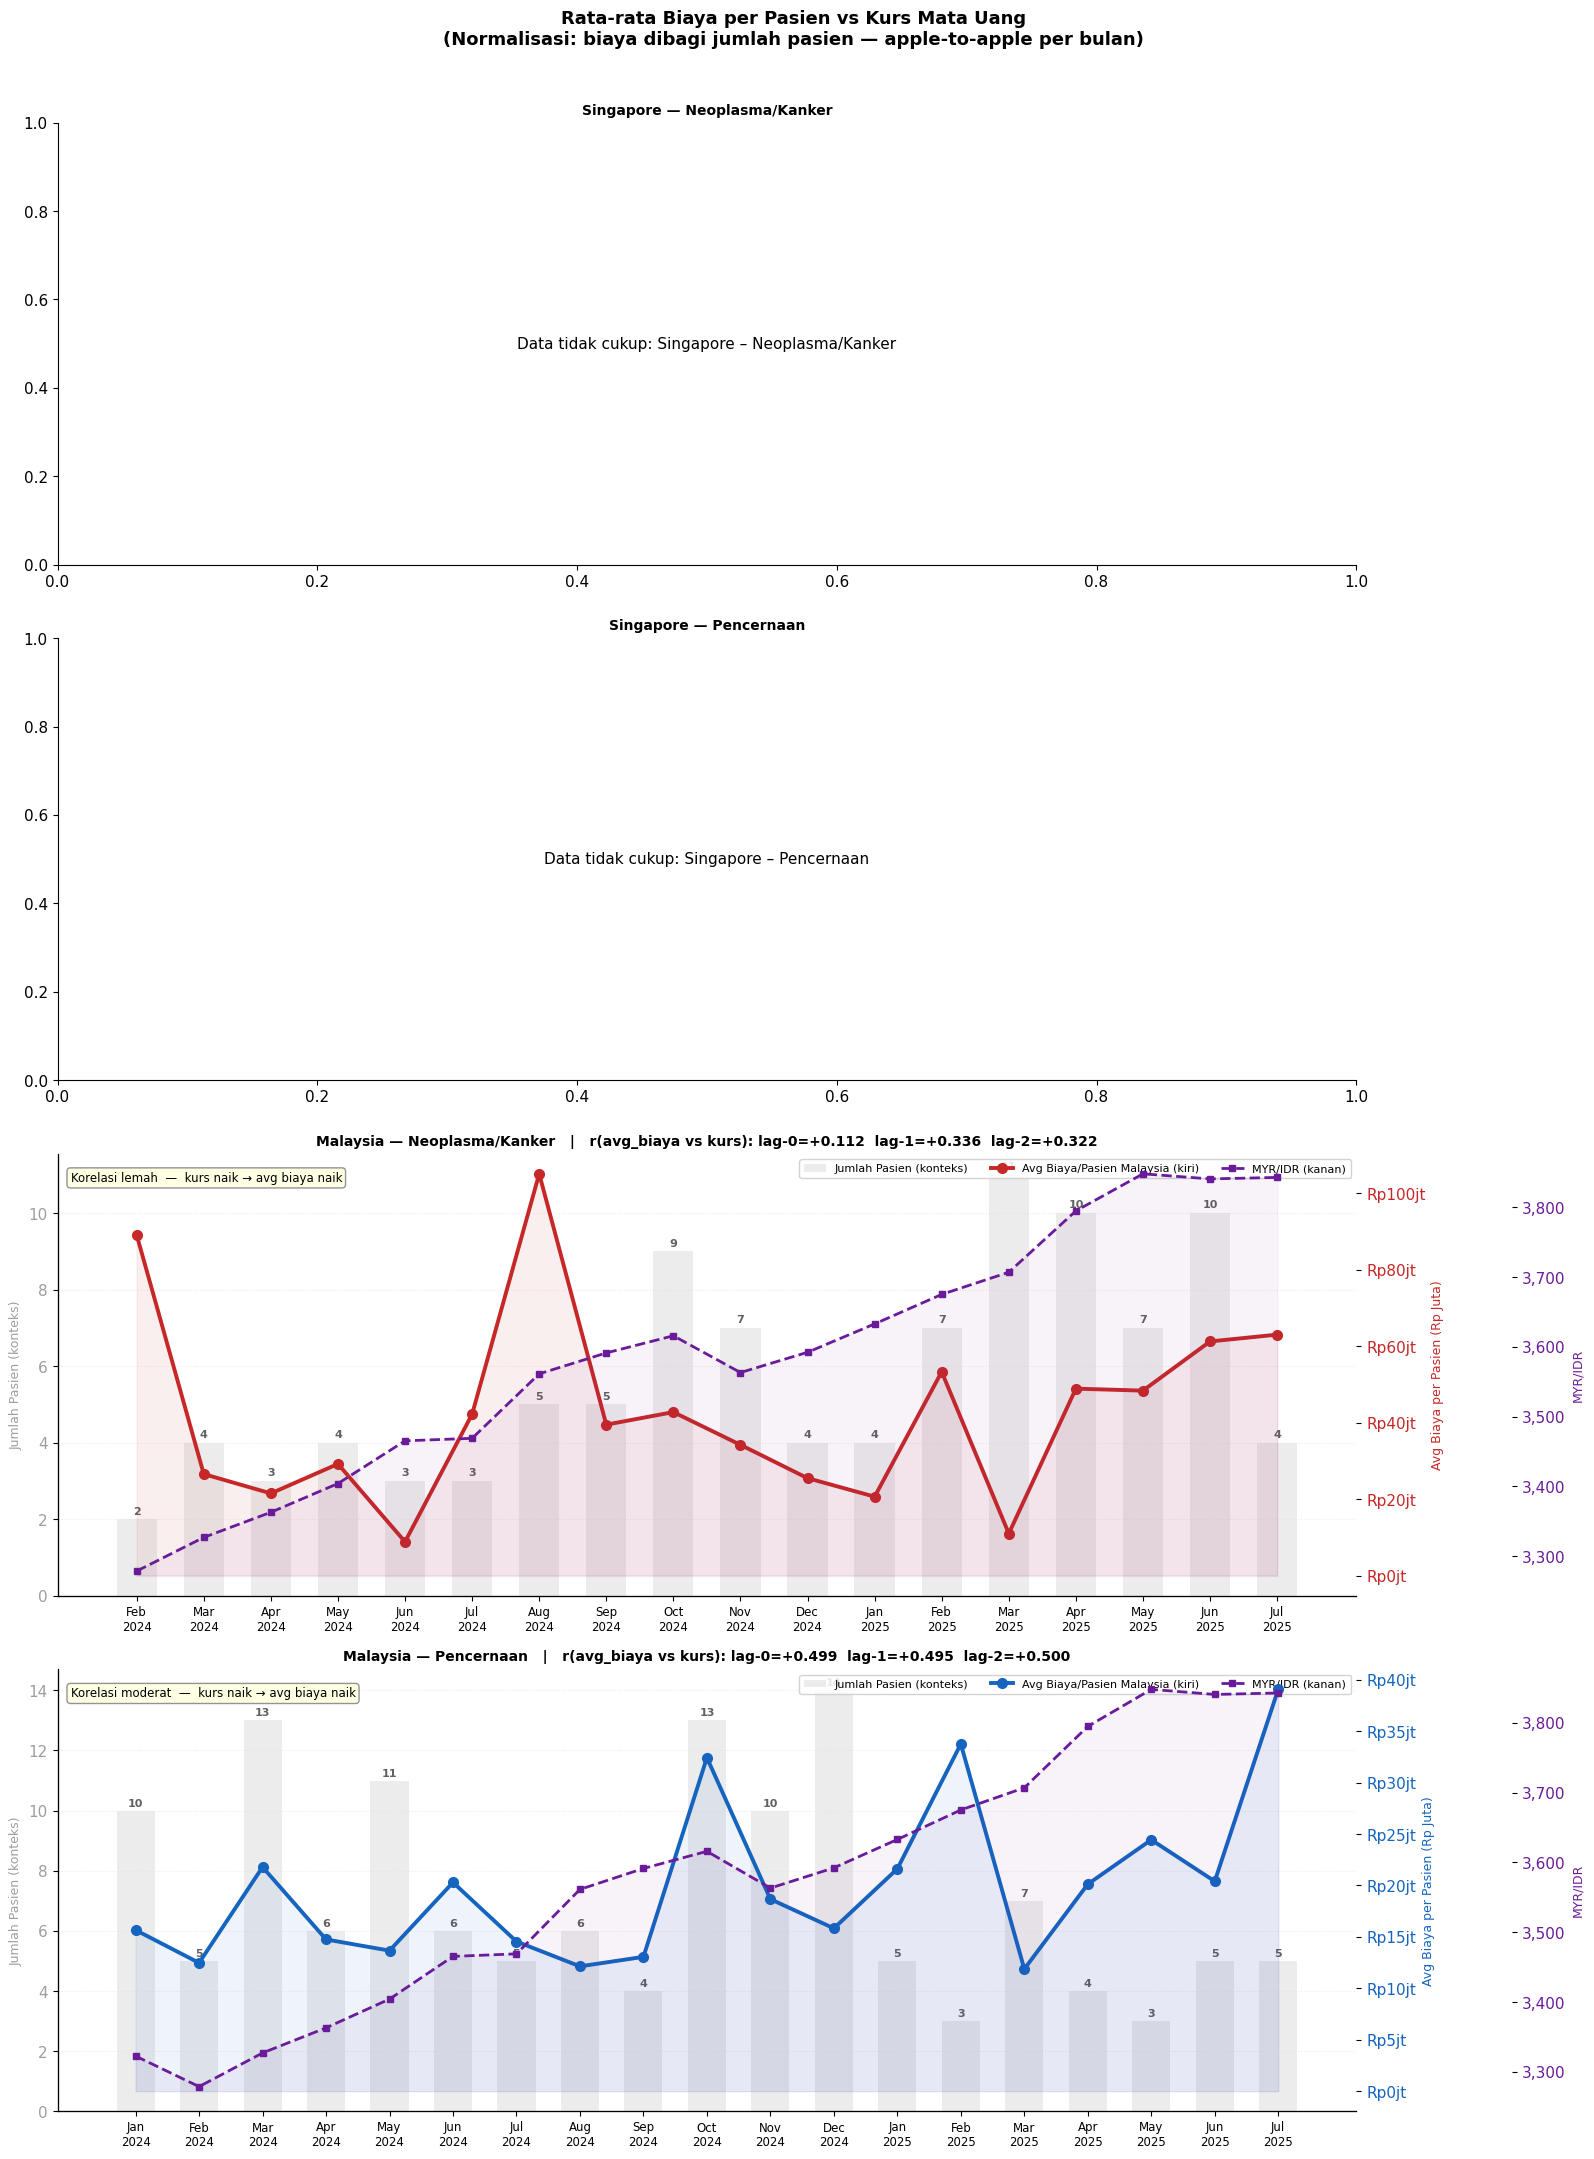

=== KORELASI AVG BIAYA/PASIEN vs KURS (Normalisasi) ===

[Singapore|Neoplasma/Kanker]: data tidak cukup (0 bln)

[Singapore|Pencernaan]: data tidak cukup (0 bln)

[Malaysia | Neoplasma/Kanker]
  Data: 18 bulan | Avg biaya/pasien: Rp42.8 juta
  r lag-0=+0.112  lag-1=+0.336  lag-2=+0.322
  → Korelasi moderat terbaik di lag-1
  Interpretasi: avg biaya/pasien naik saat kurs melemah (IDR depresiasi)

[Malaysia | Pencernaan]
  Data: 19 bulan | Avg biaya/pasien: Rp19.8 juta
  r lag-0=+0.499  lag-1=+0.495  lag-2=+0.500
  → Korelasi KUAT terbaik di lag-2
  Interpretasi: avg biaya/pasien naik saat kurs melemah (IDR depresiasi)



In [45]:
# ── Phase 9.7 (Normalisasi): Avg Biaya per Pasien vs Kurs ─────────────
# Normalisasi: total_nom / n_pasien = rata-rata biaya per pasien per bulan
# Apples-to-apples: berapapun jumlah pasien, kita bandingkan biaya per kepala vs kurs

ICD_DOMINAN = ['Neoplasma/Kanker', 'Pencernaan']
CONFIGS_97 = [
    ('Singapore', 'Neoplasma/Kanker', sgd_m, 'SGD', 'SGD/IDR', '#C62828', '#2E7D32'),
    ('Singapore', 'Pencernaan',       sgd_m, 'SGD', 'SGD/IDR', '#1565C0', '#2E7D32'),
    ('Malaysia',  'Neoplasma/Kanker', myr_m, 'MYR', 'MYR/IDR', '#C62828', '#6A1B9A'),
    ('Malaysia',  'Pencernaan',       myr_m, 'MYR', 'MYR/IDR', '#1565C0', '#6A1B9A'),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle(
    'Rata-rata Biaya per Pasien vs Kurs Mata Uang\n'
    '(Normalisasi: biaya dibagi jumlah pasien — apple-to-apple per bulan)',
    fontsize=13, fontweight='bold'
)

for ax, (lokasi, icd, fx_df, fx_col, fx_label, c_biaya, c_kurs) in zip(axes, CONFIGS_97):
    # Aggregate
    sub = df_raw[
        (df_raw['Lokasi RS'] == lokasi) &
        (df_raw['ICD_Group'] == icd)
    ].groupby('bulan').agg(
        n_pasien  = ('Claim ID',                    'count'),
        total_nom = ('Nominal Klaim Yang Disetujui', 'sum'),
    ).reset_index()
    sub['bulan'] = pd.to_datetime(sub['bulan'])
    sub['avg_biaya'] = sub['total_nom'] / sub['n_pasien']   # ← normalisasi

    # Merge FX
    fx_clean = fx_df.copy()
    fx_clean['bulan'] = pd.to_datetime(fx_clean['bulan'])
    sub = sub.merge(fx_clean, on='bulan', how='inner')
    sub = sub[sub['bulan'] >= '2024-01-01'].sort_values('bulan')

    if sub.empty or len(sub) < 3:
        ax.text(0.5, 0.5, f'Data tidak cukup: {lokasi} – {icd}',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(f'{lokasi} — {icd}', fontweight='bold', fontsize=10)
        continue

    x     = range(len(sub))
    xlbls = [b.strftime('%b\n%Y') for b in sub['bulan']]

    # Bar: jumlah pasien (konteks, bukan ukuran utama)
    ax.bar(x, sub['n_pasien'], color='#E0E0E0', alpha=0.6, width=0.6,
           label='Jumlah Pasien (konteks)', zorder=2)
    for xi, ni in zip(x, sub['n_pasien']):
        ax.text(xi, ni + 0.08, str(int(ni)), ha='center', va='bottom',
                fontsize=8, color='#616161', fontweight='bold')
    ax.set_ylabel('Jumlah Pasien (konteks)', color='#9E9E9E', fontsize=9)
    ax.tick_params(axis='y', labelcolor='#9E9E9E')

    # Line kiri 2 (sumbu kedua kiri): avg biaya per pasien
    ax_biaya = ax.twinx()
    ax_biaya.spines['right'].set_position(('axes', 1.0))
    ax_biaya.plot(x, sub['avg_biaya'] / 1e6, color=c_biaya, lw=2.8, marker='o', ms=7,
                  label=f'Avg Biaya/Pasien {lokasi} (kiri)', zorder=4)
    ax_biaya.fill_between(x, sub['avg_biaya'] / 1e6, 0, alpha=0.07, color=c_biaya)
    ax_biaya.set_ylabel('Avg Biaya per Pasien (Rp Juta)', color=c_biaya, fontsize=9)
    ax_biaya.tick_params(axis='y', labelcolor=c_biaya)
    ax_biaya.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'Rp{v:.0f}jt'))

    # Line kanan: kurs
    ax_kurs = ax.twinx()
    ax_kurs.spines['right'].set_position(('axes', 1.12))
    ax_kurs.plot(x, sub[fx_col], color=c_kurs, lw=2, ls='--', marker='s', ms=5,
                 label=f'{fx_label} (kanan)', zorder=3)
    ax_kurs.fill_between(x, sub[fx_col], sub[fx_col].min() * 0.998,
                         alpha=0.05, color=c_kurs)
    ax_kurs.set_ylabel(f'{fx_label}', color=c_kurs, fontsize=9)
    ax_kurs.tick_params(axis='y', labelcolor=c_kurs)
    ax_kurs.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

    # Korelasi avg_biaya vs kurs
    r0  = sub['avg_biaya'].corr(sub[fx_col])
    rl1 = sub['avg_biaya'].corr(sub[fx_col].shift(1))
    r2  = sub['avg_biaya'].corr(sub[fx_col].shift(2))

    ax.set_xticks(list(x))
    ax.set_xticklabels(xlbls, fontsize=8.5)
    ax.set_title(
        f'{lokasi} — {icd}   |   r(avg_biaya vs kurs): lag-0={r0:+.3f}  lag-1={rl1:+.3f}  lag-2={r2:+.3f}',
        fontweight='bold', fontsize=10
    )
    ax.grid(axis='y', ls=':', alpha=0.25)

    # Korelasi annotation
    interp = "KUAT" if abs(r0) >= 0.5 else ("moderat" if abs(r0) >= 0.3 else "lemah")
    arah   = "naik" if r0 > 0 else "turun"
    ax.text(0.01, 0.96,
            f'Korelasi {interp}  —  kurs naik → avg biaya {arah}',
            transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.85))

    # Legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_biaya.get_legend_handles_labels()
    h3, l3 = ax_kurs.get_legend_handles_labels()
    ax.legend(h1 + h2 + h3, l1 + l2 + l3, fontsize=8, loc='upper right',
              ncol=3, framealpha=0.85)

plt.tight_layout(rect=[0, 0, 1, 0.97])
import os; os.makedirs('charts', exist_ok=True)
plt.savefig('charts/avg_biaya_per_pasien_vs_kurs.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Ringkasan korelasi ────────────────────────────────────────────────
print("=== KORELASI AVG BIAYA/PASIEN vs KURS (Normalisasi) ===\n")
for lokasi, icd, fx_df, fx_col, fx_label, _, _ in CONFIGS_97:
    sub = df_raw[
        (df_raw['Lokasi RS'] == lokasi) &
        (df_raw['ICD_Group'] == icd)
    ].groupby('bulan').agg(
        n_pasien  = ('Claim ID', 'count'),
        total_nom = ('Nominal Klaim Yang Disetujui', 'sum'),
    ).reset_index()
    sub['bulan']     = pd.to_datetime(sub['bulan'])
    sub['avg_biaya'] = sub['total_nom'] / sub['n_pasien']
    sub = sub.merge(fx_df.copy().assign(bulan=lambda d: pd.to_datetime(d['bulan'])),
                    on='bulan', how='inner')
    sub = sub[sub['bulan'] >= '2024-01-01']
    if len(sub) < 4:
        print(f"[{lokasi}|{icd}]: data tidak cukup ({len(sub)} bln)\n")
        continue
    r0  = sub['avg_biaya'].corr(sub[fx_col])
    rl1 = sub['avg_biaya'].corr(sub[fx_col].shift(1))
    r2  = sub['avg_biaya'].corr(sub[fx_col].shift(2))
    best_r   = max(abs(r0), abs(rl1), abs(r2))
    best_lag = ['lag-0','lag-1','lag-2'][[abs(r0),abs(rl1),abs(r2)].index(best_r)]
    interp   = "KUAT" if best_r >= 0.5 else ("moderat" if best_r >= 0.3 else "lemah")
    avg_byr  = sub['avg_biaya'].mean()
    print(f"[{lokasi} | {icd}]")
    print(f"  Data: {len(sub)} bulan | Avg biaya/pasien: Rp{avg_byr/1e6:.1f} juta")
    print(f"  r lag-0={r0:+.3f}  lag-1={rl1:+.3f}  lag-2={r2:+.3f}")
    print(f"  → Korelasi {interp} terbaik di {best_lag}")
    if best_r >= 0.3:
        arah = "naik saat kurs melemah (IDR depresiasi)" if r0 > 0 else "bergerak berlawanan kurs"
        print(f"  Interpretasi: avg biaya/pasien {arah}")
    print()